## Drive & imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os
from datetime import datetime


# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import os
import cv2
import numpy as np
import glob
import json

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch, gc
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
!pip install torchview
from torchview import draw_graph
import torch.optim as optim


# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.gridspec as gridspec


# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


In [ ]:
!pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.3 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import shutil
import zipfile
from google.colab import files

## Loading resized images and masks

In [ ]:
# @title Loading fun (ZIP)

import os
import zipfile
import pandas as pd
import cv2
import numpy as np
from tqdm import tqdm


def load_processed_data(
    dataset_path,
    extract_root="/content",
    force_unzip=False
):

    # =========================
    # Gestione ZIP
    # =========================
    if str(dataset_path).lower().endswith(".zip"):
        zip_path = dataset_path
        dataset_name = os.path.splitext(os.path.basename(zip_path))[0]
        dataset_dir = os.path.join(extract_root, dataset_name)

        if force_unzip and os.path.exists(dataset_dir):
            import shutil
            shutil.rmtree(dataset_dir)

        if not os.path.exists(dataset_dir):
            print(f"📦 Estrazione ZIP → {dataset_dir}")
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(extract_root)
        else:
            print(f"ZIP già estratto: {dataset_dir}")
    else:
        dataset_dir = dataset_path

    print(f"\n📂 Dataset dir: {dataset_dir}")

    # =========================
    # Controlli struttura
    # =========================
    labels_path = os.path.join(dataset_dir, "labels.csv")
    images_dir = os.path.join(dataset_dir, "images")
    masks_dir  = os.path.join(dataset_dir, "masks")

    for p in [labels_path, images_dir, masks_dir]:
        if not os.path.exists(p):
            raise FileNotFoundError(f" Struttura non valida, manca: {p}")

    # =========================
    # Lettura CSV
    # =========================
    df = pd.read_csv(labels_path)
    total = len(df)
    print(f" Trovate {total} immagini")

    X, y, masks, filenames = [], [], [], []

    # =========================
    # Caricamento dati
    # =========================
    for _, row in tqdm(df.iterrows(), total=total):
        fname = row["filename"]
        label = row["class_index"]

        img_path  = os.path.join(images_dir, fname)
        mask_path = os.path.join(masks_dir, fname)

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print(f"⚠️ Errore caricamento: {fname}")
            continue

        X.append(img)
        masks.append(mask)
        y.append(label)
        filenames.append(fname)

    X = np.array(X)
    y = np.array(y)
    masks = np.array(masks)

    print("\n Dataset caricato correttamente")
    print(f"   X      : {X.shape}")
    print(f"   y      : {y.shape}")
    print(f"   masks  : {masks.shape}")

    return X, y, masks, filenames

In [ ]:

BASE_ROOT=Path('/content/drive/MyDrive/PROGETTO AI')
data=BASE_ROOT/'DATA RESIZED.zip'

X_train_val, y_train_val, masks_train_val, loaded_filenames = load_processed_data(data)


📦 Estrazione ZIP → /content/DATA RESIZED

📂 Dataset dir: /content/DATA RESIZED
 Trovate 1503 immagini


100%|██████████| 1503/1503 [00:03<00:00, 407.05it/s]



 Dataset caricato correttamente
   X      : (1503, 256, 256, 3)
   y      : (1503,)
   masks  : (1503, 256, 256)


In [ ]:
# @title Random Samples Visualization
import matplotlib.pyplot as plt
import numpy as np
import random

# Definizione mappa classi
class_map = {0: 'Benign', 1: 'Malignant', 2: 'Normal'}

def visualize_random_samples(X, y, filenames, num_samples=9):
    """
    Visualizza campioni casuali mostrando anche il nome del file originale.
    """
    plt.figure(figsize=(15, 15))

    # Genera indici casuali
    # Assicuriamoci di non chiedere più campioni di quanti ne abbiamo
    num_samples = min(num_samples, len(X))
    indices = np.random.choice(len(X), num_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(3, 3, i + 1)

        # Gestione visualizzazione (se float 0-1 o uint8 0-255)
        img = X[idx]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        plt.imshow(img)

        label_idx = y[idx]
        label_name = class_map.get(label_idx, "Unknown")

        # Recupera il nome del file corrispondente all'indice
        file_name = filenames[idx]

        # Titolo con tutte le info (uso \n per andare a capo)
        plt.title(f"Idx: {idx} | {file_name}\nClass: {label_name} ({label_idx})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

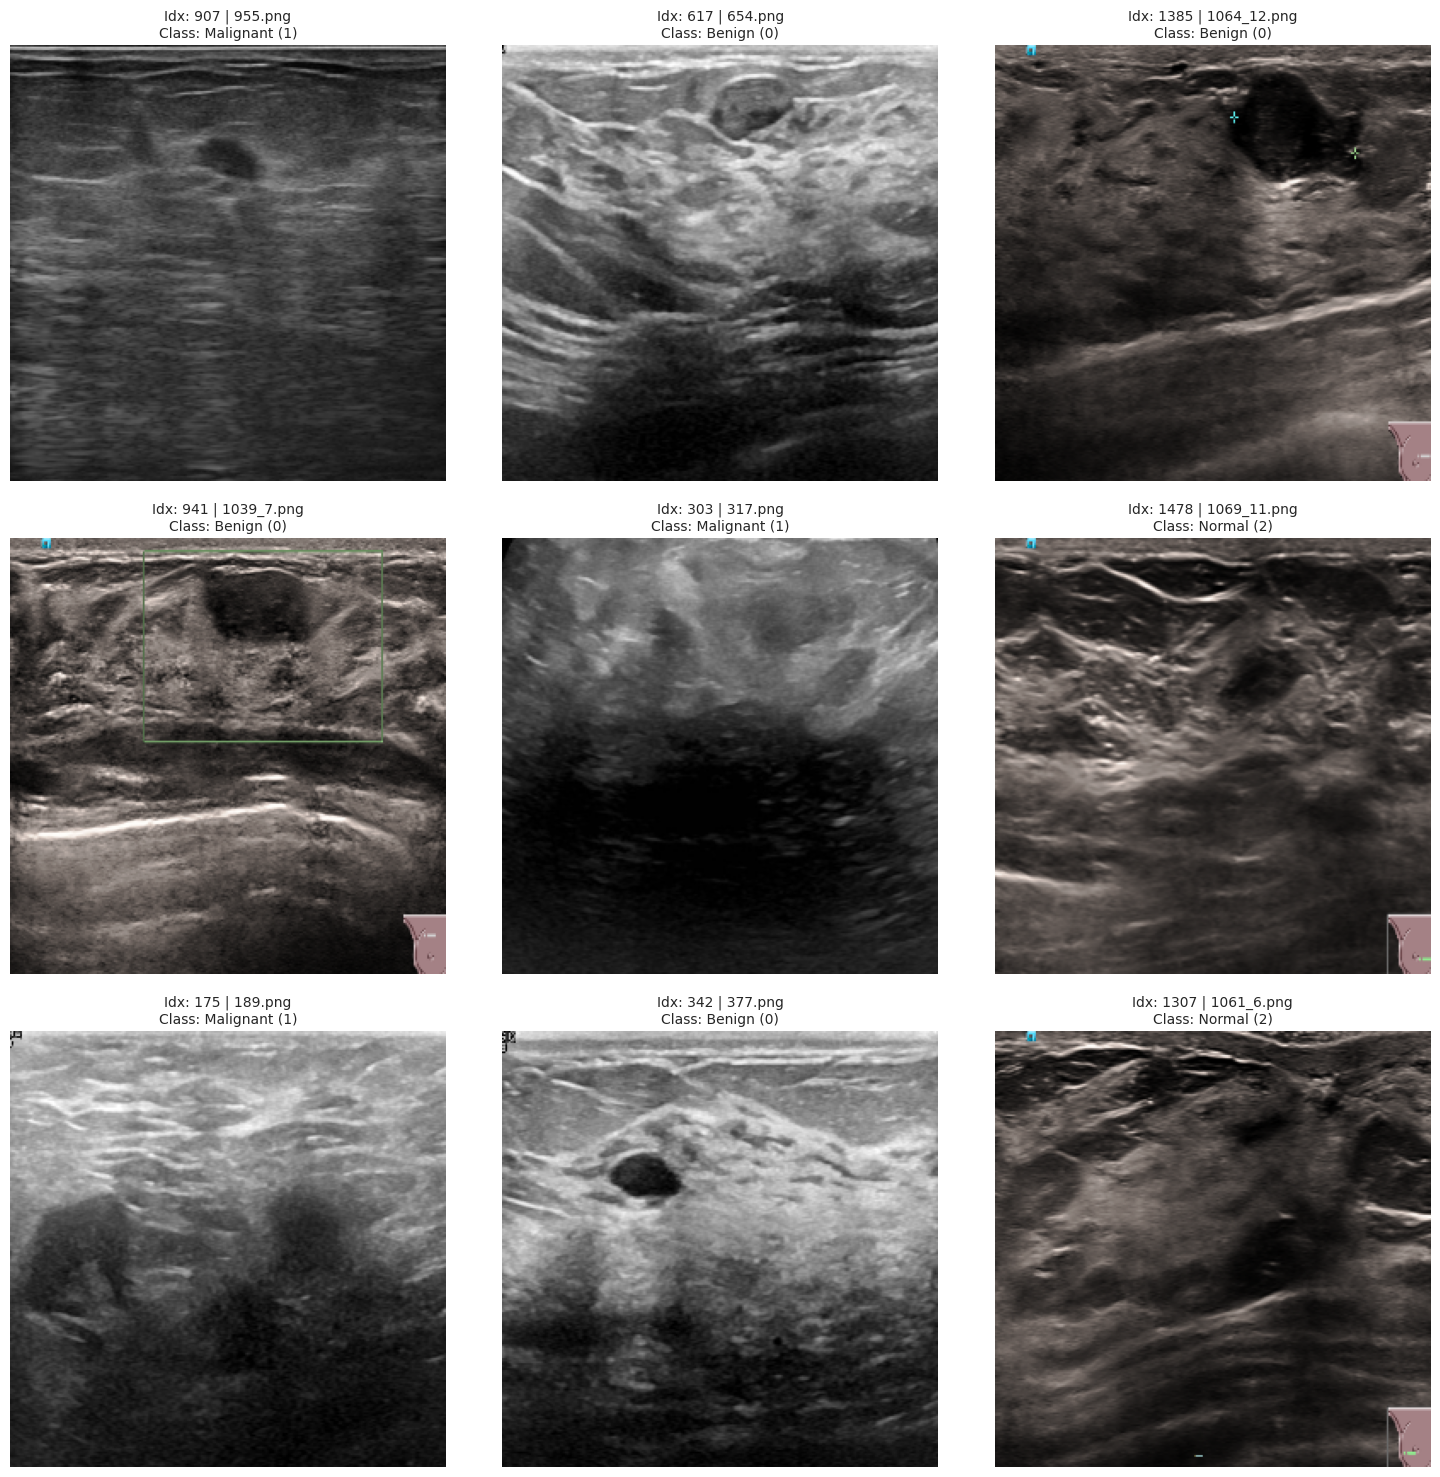

In [ ]:
visualize_random_samples(X_train_val, y_train_val, loaded_filenames)

## Preprocessing

### CLAHE

In [ ]:
# @title CLAHE fun
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_grayscale_and_clahe(X):
    """
    1. Converte immagini RGB in Grayscale.
    2. Applica CLAHE con parametri da paper (ClipLimit=4.0, Grid=8x8).

    Input: Array (N, H, W, 3) o (N, H, W)
    Output: Array (N, H, W, 1) pronto per la rete.
    """
    print(f"Applicazione Grayscale + CLAHE (Clip: 4.0, Grid: 8x8)...")

    # Inizializza l'oggetto CLAHE con i parametri richiesti
    # clipLimit=4.0 rende il contrasto molto forte (utile per bordi tumorali)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))

    X_processed = []

    for i in range(len(X)):
        img = X[i]

        # --- CHECK VALIDITÀ (UINT8) ---
        # OpenCV CLAHE lavora su uint8 (0-255). Se i dati sono float 0-1, convertiamo.
        if img.dtype == 'float32' or img.dtype == 'float64':
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

        # --- 1. CONVERSIONE GRAYSCALE ---
        # Se l'immagine ha 3 canali, la convertiamo. Se ne ha già 1 o 0 (flat), saltiamo.
        if len(img.shape) == 3 and img.shape[2] == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            # Se è già in scala di grigi (es. 256, 256) o (256, 256, 1)
            gray = img
            if len(gray.shape) == 3: # Rimuovi dimensione canale inutile se c'è
                gray = gray[:, :, 0]

        # --- 2. APPLICAZIONE CLAHE ---
        img_clahe = clahe.apply(gray)

        X_processed.append(img_clahe)

    # Conversione in array Numpy
    X_processed = np.array(X_processed)

    # --- RESHAPE FINALE ---
    # Le reti (come U-Net o ResNet) si aspettano un canale esplicito: (N, 256, 256, 1)
    # Attualmente X_processed è (N, 256, 256)
    X_final = np.expand_dims(X_processed, axis=-1)

    print(f"Processamento completato.")
    print(f"   Shape finale: {X_final.shape}")

    return X_final

Applicazione Grayscale + CLAHE (Clip: 4.0, Grid: 8x8)...
Processamento completato.
   Shape finale: (1503, 256, 256, 1)


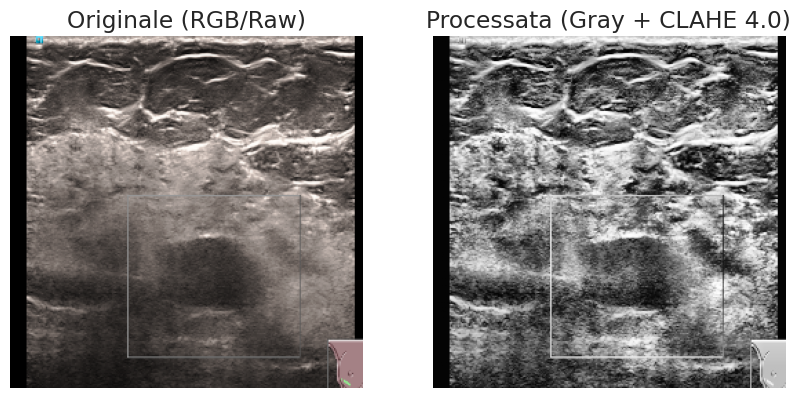

In [ ]:

X_train_val_clahe = apply_grayscale_and_clahe(X_train_val)

idx = np.random.randint(0, len(X_train_val))

plt.figure(figsize=(10, 5))

# Immagine Originale
plt.subplot(1, 2, 1)
if X_train_val[idx].shape[-1] == 3:
    plt.imshow(X_train_val[idx])
else:
    plt.imshow(X_train_val[idx].squeeze(), cmap='gray')
plt.title("Originale (RGB/Raw)")
plt.axis('off')

# Immagine Processata (CLAHE 4.0)
plt.subplot(1, 2, 2)
plt.imshow(X_train_val_clahe[idx].squeeze(), cmap='gray')
plt.title("Processata (Gray + CLAHE 4.0)")
plt.axis('off')

plt.show()

## TRAIN - VAL - TEST split

In [ ]:
""" Struttura

holdout/
  TrainVal.csv
  Test.csv

fold_TV/
  fold_0_TV.csv
  fold_1_TV.csv
  fold_2_TV.csv

dataset completo
   ↓
HOLDOUT split (pazienti)
   ↓
TrainVal subset ───────────→ Test subset
   ↓
kfold_split(TrainVal subset)
   ↓
save_kfold_metadata → fold_0_TV.csv, fold_1_TV.csv, fold_2_TV.csv

"""

In [ ]:
# @title step 1) Hold out TrainVal + Test

from sklearn.model_selection import StratifiedShuffleSplit

def holdout_split(
    y,
    filenames,
    test_size=0.1,
    random_state=42,
    patient_id_fn=None,
    class_priority=None,
    verbose=True
):
    if patient_id_fn is None:
        patient_id_fn = lambda fn: str(fn).split("_")[0].split(".")[0]

    if class_priority is None:
        class_priority = [1, 0, 2]  # MAL 1 > BEN 0 > NORMAL 2

    df = pd.DataFrame({
        "filename": np.asarray(filenames),
        "label_orig": np.asarray(y),
        "idx": np.arange(len(y))
    })
    df["patient_id"] = df["filename"].apply(patient_id_fn)

    if verbose:
        print("="*60)
        print("1. HOLDOUT SPLIT PAZIENTI (TrainVal vs Test)")
        print("="*60)
        print(f"Totale Immagini: {len(df)}")
        print(f"Totale Pazienti: {df['patient_id'].nunique()}")

    # --- Patient priority label ---
    def get_patient_priority_label(patient_labels):
        classes_present = set(patient_labels)
        for c in class_priority:
            if c in classes_present:
                return c
        return list(classes_present)[0]

    patient_strat_labels = df.groupby("patient_id")["label_orig"].apply(get_patient_priority_label)
    unique_patients = patient_strat_labels.index.values
    stratify_values = patient_strat_labels.values

    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    p_tv_idx, p_test_idx = next(sss.split(unique_patients, stratify_values))

    patients_tv = unique_patients[p_tv_idx]
    patients_test = unique_patients[p_test_idx]

    # leakage check pazienti
    inter = set(patients_tv).intersection(set(patients_test))
    if len(inter) > 0:
        raise RuntimeError(f"LEAKAGE holdout! Pazienti in comune TrainVal/Test: {list(inter)[:5]}")

    df_tv = df[df["patient_id"].isin(patients_tv)].copy()
    df_test = df[df["patient_id"].isin(patients_test)].copy()

    def print_stats(df_, name):
        unique, counts = np.unique(df_["label_orig"].values, return_counts=True)
        tot = len(df_)
        print(f"Distribuzione Immagini {name}:")
        for u, c in zip(unique, counts):
            print(f"  Classe {u}: {c} ({c/tot*100:.1f}%)")

    if verbose:
        print(f"\nTrainVal: {len(df_tv)} immagini ({df_tv['patient_id'].nunique()} pazienti)")
        print(f"Test:     {len(df_test)} immagini ({df_test['patient_id'].nunique()} pazienti)")
        print_stats(df_tv, "TRAINVAL")
        print_stats(df_test, "TEST")

    return df_tv, df_test

In [ ]:
# @title Salva metadata hold out
def save_holdout_metadata(df_tv, df_test, out_dir="holdout"):
    os.makedirs(out_dir, exist_ok=True)

    def _prep(df_, split_name):
        out = df_[["idx", "filename", "label_orig"]].copy()
        out = out.rename(columns={"label_orig": "label"})
        out["split"] = split_name
        out = out[["idx", "filename", "label", "split"]]
        return out

    df_tv_out = _prep(df_tv, "trainval")
    df_test_out = _prep(df_test, "test")

    df_tv_out.to_csv(os.path.join(out_dir, "TrainVal.csv"), index=False)
    df_test_out.to_csv(os.path.join(out_dir, "Test.csv"), index=False)

    print(f"[OK] Salvato {out_dir}/TrainVal.csv (n={len(df_tv_out)})")
    print(f"[OK] Salvato {out_dir}/Test.csv (n={len(df_test_out)})")


In [ ]:
TEST_SIZE = 0.1
HOLDOUT_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout"

df_tv, df_test = holdout_split(
    y=y_train_val,
    filenames=loaded_filenames,
    test_size=TEST_SIZE,
    random_state=SEED,
)

save_holdout_metadata(df_tv, df_test, out_dir=HOLDOUT_DIR)

1. HOLDOUT SPLIT PAZIENTI (TrainVal vs Test)
Totale Immagini: 1503
Totale Pazienti: 968

TrainVal: 1384 immagini (871 pazienti)
Test:     119 immagini (97 pazienti)
Distribuzione Immagini TRAINVAL:
  Classe 0: 620 (44.8%)
  Classe 1: 328 (23.7%)
  Classe 2: 436 (31.5%)
Distribuzione Immagini TEST:
  Classe 0: 59 (49.6%)
  Classe 1: 36 (30.3%)
  Classe 2: 24 (20.2%)
[OK] Salvato /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout/TrainVal.csv (n=1384)
[OK] Salvato /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout/Test.csv (n=119)


In [ ]:
# @title check no leakage

HOLDOUT_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout"

df_tv   = pd.read_csv(f"{HOLDOUT_DIR}/TrainVal.csv")
df_test = pd.read_csv(f"{HOLDOUT_DIR}/Test.csv")

print("TrainVal:", df_tv.shape)
print("Test    :", df_test.shape)

#####

inter_idx = set(df_tv["idx"]).intersection(set(df_test["idx"]))
print("Overlap idx TrainVal/Test:", len(inter_idx))

if len(inter_idx) > 0:
    print("Esempi:", list(inter_idx)[:10])
else:
    print("✅ OK: nessun idx condiviso")

#####

inter_fn = set(df_tv["filename"]).intersection(set(df_test["filename"]))
print("Overlap filename TrainVal/Test:", len(inter_fn))

if len(inter_fn) > 0:
    print("Esempi:", list(inter_fn)[:10])
else:
    print("✅ OK: nessun filename condiviso")

####

def patient_id_fn(x):
    return str(x).split('_')[0]

df_tv["patient_id"]   = df_tv["filename"].apply(patient_id_fn)
df_test["patient_id"] = df_test["filename"].apply(patient_id_fn)

inter_p = set(df_tv["patient_id"]).intersection(set(df_test["patient_id"]))
print("Overlap patient_id TrainVal/Test:", len(inter_p))

if len(inter_p) > 0:
    print("⚠️ Pazienti in comune:", list(inter_p)[:10])
else:
    print("✅ OK: nessun paziente condiviso")


####
print("TrainVal unique idx:", df_tv["idx"].nunique())
print("Test unique idx    :", df_test["idx"].nunique())

tot = df_tv["idx"].nunique() + df_test["idx"].nunique()
print("Totale immagini coperte:", tot)



TrainVal: (1384, 4)
Test    : (119, 4)
Overlap idx TrainVal/Test: 0
✅ OK: nessun idx condiviso
Overlap filename TrainVal/Test: 0
✅ OK: nessun filename condiviso
Overlap patient_id TrainVal/Test: 0
✅ OK: nessun paziente condiviso
TrainVal unique idx: 1384
Test unique idx    : 119
Totale immagini coperte: 1503


In [ ]:
# @title step 2) k-fold su TrainVal

from sklearn.model_selection import StratifiedKFold

def kfold_split(
    y,
    filenames,
    n_splits=5,
    random_state=42,
    shuffle=True,
    patient_id_fn=None,
    class_priority=None,
    idx_global=None,
    verbose=True
):
    if patient_id_fn is None:
        patient_id_fn = lambda fn: str(fn).split("_")[0].split(".")[0]

    if class_priority is None:
        class_priority = [1, 0, 2]

    if idx_global is None:
        idx_arr = np.arange(len(y))
    else:
        idx_arr = np.asarray(idx_global).astype(int)
        if len(idx_arr) != len(y):
            raise ValueError("idx_global deve avere stessa lunghezza di y/filenames.")

    df = pd.DataFrame({
        "filename": np.asarray(filenames),
        "label_orig": np.asarray(y),
        "idx": idx_arr
    })
    df["patient_id"] = df["filename"].apply(patient_id_fn)

    if verbose:
        print("="*60)
        print("1. PREPARAZIONE DATI E METADATI")
        print("="*60)
        print(f"Totale Immagini: {len(df)}")
        print(f"Totale Pazienti: {df['patient_id'].nunique()}")

    def get_patient_priority_label(patient_labels):
        classes_present = set(patient_labels)
        for c in class_priority:
            if c in classes_present:
                return c
        return list(classes_present)[0]

    patient_strat_labels = df.groupby("patient_id")["label_orig"].apply(get_patient_priority_label)
    unique_patients = patient_strat_labels.index.values
    stratify_values = patient_strat_labels.values

    if verbose:
        print("\n" + "="*60)
        print(f"2. K-FOLD SPLIT PAZIENTI (n_splits={n_splits}, stratificato su label prioritaria)")
        print("="*60)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    folds = []

    def print_stats(y_arr, name):
        unique, counts = np.unique(y_arr, return_counts=True)
        tot = len(y_arr)
        print(f"Distribuzione Immagini {name}:")
        for u, c in zip(unique, counts):
            print(f"  Classe {u}: {c} ({c/tot*100:.1f}%)")

    for fold_id, (p_train_idx, p_val_idx) in enumerate(skf.split(unique_patients, stratify_values)):
        patients_train = unique_patients[p_train_idx]
        patients_val = unique_patients[p_val_idx]

        df_train = df[df["patient_id"].isin(patients_train)]
        df_val = df[df["patient_id"].isin(patients_val)]

        train_idx = df_train["idx"].values.astype(int)
        val_idx = df_val["idx"].values.astype(int)

        inter = set(df_train["patient_id"]).intersection(set(df_val["patient_id"]))
        if len(inter) > 0:
            raise RuntimeError(f"LEAKAGE! Pazienti in comune tra train e val nel fold {fold_id}: {list(inter)[:5]}")

        if verbose:
            print(f"\n[FOLD {fold_id}]")
            print(f"Train: {len(train_idx)} immagini ({len(patients_train)} pazienti)")
            print(f"Val:   {len(val_idx)} immagini ({len(patients_val)} pazienti)")
            print_stats(df_train["label_orig"].values, "TRAIN")
            print_stats(df_val["label_orig"].values, "VALIDATION")

        folds.append({
            "fold": fold_id,
            "patients_train": patients_train,
            "patients_val": patients_val,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "filenames_train": df_train["filename"].values,
            "filenames_val": df_val["filename"].values
        })

    if verbose:
        print("\n" + "="*60)
        print("K-FOLD COMPLETATO.")
        print("="*60)

    return folds


In [ ]:
# @title Salva metadata Train Val split

def save_kfold_metadata(folds, y, filenames, out_dir="splits"):
    os.makedirs(out_dir, exist_ok=True)

    for f in folds:
        fold_id = f["fold"]

        rows = []

        # TRAIN
        for idx in f["train_idx"]:
            rows.append({
                "idx": int(idx),
                "filename": filenames[idx],
                "patient_id": str(filenames[idx]).split("_")[0],
                "label": int(y[idx]),
                "split": "train"
            })

        # VAL
        for idx in f["val_idx"]:
            rows.append({
                "idx": int(idx),
                "filename": filenames[idx],
                "patient_id": str(filenames[idx]).split("_")[0],
                "label": int(y[idx]),
                "split": "val"
            })

        df_fold = pd.DataFrame(rows)
        df_fold.to_csv(f"{out_dir}/fold_{fold_id}.csv", index=False)

        print(f"[OK] Salvato {out_dir}/fold_{fold_id}.csv  "
              f"(train={sum(df_fold.split=='train')}, val={sum(df_fold.split=='val')})")


In [ ]:
tv_idx = df_tv["idx"].values.astype(int)

tv_idx = df_tv["idx"].values.astype(int)

assert tv_idx.min() >= 0 and tv_idx.max() < len(y_train_val)
assert len(tv_idx) == len(np.unique(tv_idx)), "Duplicati in tv_idx!"

y_tv  = np.asarray(y_train_val)[tv_idx]
fn_tv = np.asarray(loaded_filenames)[tv_idx]

assert np.all(fn_tv == df_tv["filename"].values), "Mismatch filename: df_tv vs loaded_filenames[tv_idx]"
assert np.all(y_tv  == df_tv["label"].values), "Mismatch label: df_tv vs y_train_val[tv_idx]"


y_tv  = np.asarray(y_train_val)[tv_idx]
fn_tv = np.asarray(loaded_filenames)[tv_idx]

N_SPLITS = 3
FOLD_TV_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_3classes"

folds_tv = kfold_split(
    y=y_tv,
    filenames=fn_tv,
    n_splits=N_SPLITS,
    random_state=SEED,
    shuffle=True,
    idx_global=tv_idx,
    verbose=True
)

save_kfold_metadata(
    folds=folds_tv,
    y=y_train_val,
    filenames=loaded_filenames,
    out_dir=FOLD_TV_DIR
)


1. PREPARAZIONE DATI E METADATI
Totale Immagini: 1384
Totale Pazienti: 871

2. K-FOLD SPLIT PAZIENTI (n_splits=3, stratificato su label prioritaria)

[FOLD 0]
Train: 824 immagini (580 pazienti)
Val:   560 immagini (291 pazienti)
Distribuzione Immagini TRAIN:
  Classe 0: 399 (48.4%)
  Classe 1: 193 (23.4%)
  Classe 2: 232 (28.2%)
Distribuzione Immagini VALIDATION:
  Classe 0: 221 (39.5%)
  Classe 1: 135 (24.1%)
  Classe 2: 204 (36.4%)

[FOLD 1]
Train: 950 immagini (581 pazienti)
Val:   434 immagini (290 pazienti)
Distribuzione Immagini TRAIN:
  Classe 0: 414 (43.6%)
  Classe 1: 232 (24.4%)
  Classe 2: 304 (32.0%)
Distribuzione Immagini VALIDATION:
  Classe 0: 206 (47.5%)
  Classe 1: 96 (22.1%)
  Classe 2: 132 (30.4%)

[FOLD 2]
Train: 994 immagini (581 pazienti)
Val:   390 immagini (290 pazienti)
Distribuzione Immagini TRAIN:
  Classe 0: 427 (43.0%)
  Classe 1: 231 (23.2%)
  Classe 2: 336 (33.8%)
Distribuzione Immagini VALIDATION:
  Classe 0: 193 (49.5%)
  Classe 1: 97 (24.9%)
  Classe 2

In [ ]:
# Debug per controllare che non ci sia leakage

# (a) Pazienti disgiunti TrainVal vs Test
tv_pat = set(df_tv["patient_id"].unique())
te_pat = set(df_test["patient_id"].unique())
assert tv_pat.isdisjoint(te_pat), "LEAKAGE: patient_id in comune tra TrainVal e Test!"
print("[OK] Nessun paziente in comune tra TrainVal e Test.")


# (b) Nessun idx del Test dentro i fold TV
test_idx_set = set(df_test["idx"].values.astype(int))

for f in folds_tv:
    fold_idx = set(f["train_idx"]).union(set(f["val_idx"]))
    inter = fold_idx.intersection(test_idx_set)
    assert len(inter) == 0, f"LEAKAGE: fold {f['fold']} contiene idx del TEST!"
print("[OK] Nessun idx del Test presente nei fold TrainVal.")


[OK] Nessun paziente in comune tra TrainVal e Test.
[OK] Nessun idx del Test presente nei fold TrainVal.


In [ ]:
# @title Step 3) K-fold su TrainVal - solo su classi B/M

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

def kfold_split_bm_from_labels_csv(
    labels_csv_path,
    idx_trainval,
    n_splits=5,
    random_state=42,
    shuffle=True,
    patient_id_fn=None,
    keep_classes=(0, 1),
    class_priority=(1, 0),
    verbose=True
):
    if patient_id_fn is None:
        patient_id_fn = lambda fn: str(fn).split("_")[0].split(".")[0]

    labels_df = pd.read_csv(labels_csv_path, sep=None, engine="python")
    if "filename" not in labels_df.columns or "class_index" not in labels_df.columns:
        raise ValueError("labels.csv deve contenere colonne: filename, class_index")

    df = labels_df.copy()
    df["idx"] = np.arange(len(df), dtype=int)
    df.rename(columns={"filename": "filename_orig", "class_index": "label_orig"}, inplace=True)

    idx_trainval = np.asarray(idx_trainval).astype(int)
    df = df[df["idx"].isin(idx_trainval)].copy()

    df = df[df["label_orig"].isin(keep_classes)].copy()
    if df.empty:
        raise RuntimeError("Dopo i filtri (TrainVal + keep_classes) non è rimasto nulla.")

    df["patient_id"] = df["filename_orig"].apply(patient_id_fn)

    if verbose:
        print("="*80)
        print("K-FOLD BINARIO (BEN/MAL) — patient-consistent su TrainVal")
        print("="*80)
        print(f"TrainVal idx passati: {len(idx_trainval)}")
        print(f"Dopo filtro BEN/MAL:  {len(df)} immagini")
        print(f"Pazienti (BEN/MAL):   {df['patient_id'].nunique()}")
        uniq, cnt = np.unique(df["label_orig"].values, return_counts=True)
        tot = len(df)
        print("Distribuzione immagini (post-filtro):")
        for u, c in zip(uniq, cnt):
            print(f"  Classe {u}: {c} ({c/tot*100:.1f}%)")

    def get_patient_priority_label(patient_labels):
        classes_present = set(patient_labels)
        for c in class_priority:
            if c in classes_present:
                return c
        return list(classes_present)[0]

    patient_strat_labels = df.groupby("patient_id")["label_orig"].apply(get_patient_priority_label)
    unique_patients = patient_strat_labels.index.values
    stratify_values = patient_strat_labels.values

    skf = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    folds = []

    def print_stats(y_arr, name):
        unique, counts = np.unique(y_arr, return_counts=True)
        tot = len(y_arr)
        print(f"Distribuzione Immagini {name}:")
        for u, c in zip(unique, counts):
            print(f"  Classe {u}: {c} ({c/tot*100:.1f}%)")

    for fold_id, (p_train_idx, p_val_idx) in enumerate(skf.split(unique_patients, stratify_values)):
        patients_train = unique_patients[p_train_idx]
        patients_val = unique_patients[p_val_idx]

        df_train = df[df["patient_id"].isin(patients_train)]
        df_val = df[df["patient_id"].isin(patients_val)]

        inter = set(df_train["patient_id"]).intersection(set(df_val["patient_id"]))
        if inter:
            raise RuntimeError(f"LEAKAGE! fold {fold_id}: pazienti in comune train/val: {list(inter)[:5]}")

        train_idx = df_train["idx"].values.astype(int)
        val_idx   = df_val["idx"].values.astype(int)

        if verbose:
            print(f"\n[FOLD {fold_id}]")
            print(f"Train: {len(train_idx)} immagini ({len(patients_train)} pazienti)")
            print(f"Val:   {len(val_idx)} immagini ({len(patients_val)} pazienti)")
            print_stats(df_train["label_orig"].values, "TRAIN")
            print_stats(df_val["label_orig"].values, "VALIDATION")

        folds.append({
            "fold": fold_id,
            "patients_train": patients_train,
            "patients_val": patients_val,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "filenames_train_orig": df_train["filename_orig"].values,
            "filenames_val_orig": df_val["filename_orig"].values,
        })

    if verbose:
        print("\n" + "="*80)
        print("K-FOLD BINARIO COMPLETATO.")
        print("="*80)

    return folds


In [ ]:
# @title Salva metadata

import os
import numpy as np
import pandas as pd

def save_kfold_metadata_bm(
    folds,
    labels_csv_path,
    out_dir="splits_bm",
    patient_id_fn=None
):
    """
    Salva fold_{k}.csv con:
    - idx (globale, coincide con il nome file processato idx.png)
    - processed_filename (idx.png)
    - orig_filename (da labels.csv)
    - patient_id (estratto da orig_filename)
    - label (0/1)
    - split (train/val)
    """
    if patient_id_fn is None:
        patient_id_fn = lambda fn: str(fn).split("_")[0].split(".")[0]

    os.makedirs(out_dir, exist_ok=True)

    labels_df = pd.read_csv(labels_csv_path, sep=None, engine="python")
    if "filename" not in labels_df.columns or "class_index" not in labels_df.columns:
        raise ValueError("labels.csv deve contenere colonne: filename, class_index")

    # idx globale = indice riga (0-based)
    labels_df = labels_df.copy()
    labels_df["idx"] = np.arange(len(labels_df), dtype=int)
    labels_df.rename(columns={"filename": "orig_filename", "class_index": "label"}, inplace=True)

    # mappa veloce idx -> (orig_filename, label, patient_id)
    labels_df["patient_id"] = labels_df["orig_filename"].apply(patient_id_fn)
    info_map = labels_df.set_index("idx")[["orig_filename", "label", "patient_id"]]

    for f in folds:
        fold_id = f["fold"]
        rows = []

        for split_name, idx_list in [("train", f["train_idx"]), ("val", f["val_idx"])]:
            for idx in idx_list:
                idx = int(idx)
                if idx not in info_map.index:
                    raise KeyError(f"idx={idx} non trovato in labels.csv (controlla allineamento indici).")

                orig_fn = info_map.loc[idx, "orig_filename"]
                lab = int(info_map.loc[idx, "label"])
                pid = info_map.loc[idx, "patient_id"]

                rows.append({
                    "idx": idx,
                    "filename": orig_fn,
                    "patient_id": pid,
                    "label": lab,
                    "split": split_name
                })

        df_fold = pd.DataFrame(rows)
        out_path = f"{out_dir}/fold_{fold_id}.csv"
        df_fold.to_csv(out_path, index=False)

        print(f"[OK] Salvato {out_path}  "
              f"(train={(df_fold.split=='train').sum()}, val={(df_fold.split=='val').sum()})")


In [ ]:

# --- idx TrainVal (globale: corrisponde a idx.png) ---
tv_idx = df_tv["idx"].values.astype(int)

# 1) range e unicità (qui len(y_train_val) deve essere il numero di immagini processate totali)
assert tv_idx.min() >= 0 and tv_idx.max() < len(y_train_val)
assert len(tv_idx) == len(np.unique(tv_idx)), "Duplicati in tv_idx!"

# 2) check di coerenza: idx.png vs labels.csv (consigliato)
LABELS_CSV_PATH = "/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/labels.csv"
labels_df = pd.read_csv(LABELS_CSV_PATH, sep=None, engine="python")

# idx globale = indice riga labels.csv (0-based)
assert len(labels_df) == len(y_train_val), (
    f"Mismatch: labels.csv ha {len(labels_df)} righe, "
    f"ma y_train_val ha {len(y_train_val)} elementi. "
    "Devono combaciare se idx = riga labels.csv."
)

# label check (opzionale ma forte): la label del dataset completo deve combaciare con labels.csv
if "class_index" in labels_df.columns:
    assert np.all(np.asarray(y_train_val).astype(int) == labels_df["class_index"].values.astype(int)), \
        "Mismatch: y_train_val vs labels.csv[class_index] (ordine/indicizzazione non allineati)"

# --- K-FOLD binario BEN/MAL (patient-consistent, stratificato a livello paziente) ---
N_SPLITS = 3
SEED = SEED
FOLD_TV_DIR_BM = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_BM"


folds_tv_bm = kfold_split_bm_from_labels_csv(
    labels_csv_path=LABELS_CSV_PATH,
    idx_trainval=tv_idx,
    n_splits=N_SPLITS,
    random_state=SEED,
    shuffle=True,
    verbose=True
)

# --- Salvataggio fold metadata (corretto per idx.png + mapping su labels.csv) ---
save_kfold_metadata_bm(
    folds=folds_tv_bm,
    labels_csv_path=LABELS_CSV_PATH,
    out_dir=FOLD_TV_DIR_BM
)


K-FOLD BINARIO (BEN/MAL) — patient-consistent su TrainVal
TrainVal idx passati: 1384
Dopo filtro BEN/MAL:  948 immagini
Pazienti (BEN/MAL):   759
Distribuzione immagini (post-filtro):
  Classe 0: 620 (65.4%)
  Classe 1: 328 (34.6%)

[FOLD 0]
Train: 621 immagini (506 pazienti)
Val:   327 immagini (253 pazienti)
Distribuzione Immagini TRAIN:
  Classe 0: 400 (64.4%)
  Classe 1: 221 (35.6%)
Distribuzione Immagini VALIDATION:
  Classe 0: 220 (67.3%)
  Classe 1: 107 (32.7%)

[FOLD 1]
Train: 645 immagini (506 pazienti)
Val:   303 immagini (253 pazienti)
Distribuzione Immagini TRAIN:
  Classe 0: 422 (65.4%)
  Classe 1: 223 (34.6%)
Distribuzione Immagini VALIDATION:
  Classe 0: 198 (65.3%)
  Classe 1: 105 (34.7%)

[FOLD 2]
Train: 630 immagini (506 pazienti)
Val:   318 immagini (253 pazienti)
Distribuzione Immagini TRAIN:
  Classe 0: 418 (66.3%)
  Classe 1: 212 (33.7%)
Distribuzione Immagini VALIDATION:
  Classe 0: 202 (63.5%)
  Classe 1: 116 (36.5%)

K-FOLD BINARIO COMPLETATO.
[OK] Salvato /con

In [ ]:
"""
Il resto del codice funziona identico, l'unica modifica da fare è sostituire nel loop
fold_csv_path=f"{out_dir}/fold_{fold_id}.csv"
con
fold_csv_path=f"{FOLD_TV_DIR}/fold_{fold_id}.csv"

dove
out_dir = "/content/drive/MyDrive/PROGETTO AI/TASK2/TASK2_metadata/folds"
FOLD_TV_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2/TASK2_metadata/folds_TV"
"""

'\nIl resto del codice funziona identico, l\'unica modifica da fare è sostituire nel loop\nfold_csv_path=f"{out_dir}/fold_{fold_id}.csv"\ncon\nfold_csv_path=f"{FOLD_TV_DIR}/fold_{fold_id}.csv"\n\ndove\nout_dir = "/content/drive/MyDrive/PROGETTO AI/TASK2/TASK2_metadata/folds"\nFOLD_TV_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2/TASK2_metadata/folds_TV"\n'

In [ ]:
# @title controllo fold
import os
import glob
import pandas as pd

def pid_fixed_from_filename(fn: str) -> str:
    # 1.png -> "1"
    # 1039_2.png -> "1039"
    return str(fn).split("_")[0].split(".")[0]

def check_folds_dir(folds_dir: str, pattern="fold_*.csv"):
    paths = sorted(glob.glob(os.path.join(folds_dir, pattern)))
    if not paths:
        raise FileNotFoundError(f"Nessun file trovato in {folds_dir} con pattern {pattern}")

    print(f"🔎 Trovati {len(paths)} fold csv in: {folds_dir}\n")

    ok_all = True

    for p in paths:
        df = pd.read_csv(p)

        required = {"idx", "filename", "patient_id", "label", "split"}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"{os.path.basename(p)}: mancano colonne {missing}")

        # normalizza split
        df["split"] = df["split"].astype(str).str.lower().str.strip()
        if not set(df["split"]).issubset({"train", "val"}):
            raise ValueError(f"{os.path.basename(p)}: split contiene valori strani: {sorted(df['split'].unique())}")

        # --- CHECK 1: stesso idx in train e val (vietato) ---
        idx_train = set(df.loc[df["split"] == "train", "idx"].astype(int))
        idx_val   = set(df.loc[df["split"] == "val", "idx"].astype(int))
        inter_idx = idx_train.intersection(idx_val)

        # --- CHECK 2: stesso patient_id (salvato) in train e val (vietato) ---
        pid_train = set(df.loc[df["split"] == "train", "patient_id"].astype(str))
        pid_val   = set(df.loc[df["split"] == "val", "patient_id"].astype(str))
        inter_pid = pid_train.intersection(pid_val)

        # --- CHECK 3: leakage usando patient_id "corretto" dal filename (super-importante) ---
        df["pid_fixed"] = df["filename"].astype(str).apply(pid_fixed_from_filename)
        pidf_train = set(df.loc[df["split"] == "train", "pid_fixed"])
        pidf_val   = set(df.loc[df["split"] == "val", "pid_fixed"])
        inter_pidf = pidf_train.intersection(pidf_val)

        # report fold
        fold_name = os.path.basename(p)
        print("=" * 90)
        print(f"📄 {fold_name}")
        print(f"  n_rows: {len(df)} | train: {(df['split']=='train').sum()} | val: {(df['split']=='val').sum()}")

        if inter_idx:
            ok_all = False
            print(f"❌ CHECK IDX leakage: {len(inter_idx)} idx compaiono sia in train che val.")
            print("   esempi idx:", sorted(list(inter_idx))[:20])
        else:
            print("✅ CHECK IDX: ok (nessun idx in entrambi train/val)")

        if inter_pid:
            ok_all = False
            print(f"❌ CHECK patient_id (salvato) leakage: {len(inter_pid)} patient_id in train e val.")
            print("   esempi patient_id:", list(inter_pid)[:20])
        else:
            print("✅ CHECK patient_id (salvato): ok (nessun paziente in entrambi)")

        if inter_pidf:
            ok_all = False
            print(f"❌ CHECK pid_fixed (da filename) leakage: {len(inter_pidf)} pazienti REALI in train e val.")
            print("   esempi pid_fixed:", list(inter_pidf)[:20])

            # stampa anche 5 righe di esempio per il primo pid leakato
            leak = list(inter_pidf)[0]
            ex = df[df["pid_fixed"] == leak].sort_values("split").head(10)
            print("\n   Esempio righe per pid_fixed leakato:")
            print(ex[["idx", "filename", "patient_id", "pid_fixed", "label", "split"]].to_string(index=False))
        else:
            print("✅ CHECK pid_fixed (da filename): ok (nessun paziente reale in entrambi)")

    print("\n" + "=" * 90)
    if ok_all:
        print("✅✅ TUTTI I FOLD OK: nessun leakage su idx e su pazienti (anche con pid_fixed).")
    else:
        print("❌❌ ATTENZIONE: trovati problemi in almeno un fold. Vedi sopra i dettagli.")
    print("=" * 90)


In [ ]:
FOLDS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_BM"  # <-- la tua dir
check_folds_dir(FOLDS_DIR)


🔎 Trovati 3 fold csv in: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_BM

📄 fold_0.csv
  n_rows: 948 | train: 621 | val: 327
✅ CHECK IDX: ok (nessun idx in entrambi train/val)
✅ CHECK patient_id (salvato): ok (nessun paziente in entrambi)
✅ CHECK pid_fixed (da filename): ok (nessun paziente reale in entrambi)
📄 fold_1.csv
  n_rows: 948 | train: 645 | val: 303
✅ CHECK IDX: ok (nessun idx in entrambi train/val)
✅ CHECK patient_id (salvato): ok (nessun paziente in entrambi)
✅ CHECK pid_fixed (da filename): ok (nessun paziente reale in entrambi)
📄 fold_2.csv
  n_rows: 948 | train: 630 | val: 318
✅ CHECK IDX: ok (nessun idx in entrambi train/val)
✅ CHECK patient_id (salvato): ok (nessun paziente in entrambi)
✅ CHECK pid_fixed (da filename): ok (nessun paziente reale in entrambi)

✅✅ TUTTI I FOLD OK: nessun leakage su idx e su pazienti (anche con pid_fixed).


## Augmentation (segm)

In [ ]:
# @title Step 1) Split -> subset train/val

def get_fold_data_from_csv(X, y, masks, filenames, fold_csv_path):
    df = pd.read_csv(fold_csv_path)

    train_idx = df[df["split"] == "train"]["idx"].values.astype(int)
    val_idx   = df[df["split"] == "val"]["idx"].values.astype(int)

    X_train = X[train_idx]
    y_train = y[train_idx]
    masks_train = masks[train_idx]
    fn_train = np.asarray(filenames)[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]
    masks_val = masks[val_idx]
    fn_val = np.asarray(filenames)[val_idx]

    return X_train, y_train, masks_train, fn_train, X_val, y_val, masks_val, fn_val


In [ ]:
# @title Step 2) Offline augmentation

import albumentations as A
import cv2
import numpy as np

def balance_dataset_offline(X_train, y_train, masks_train, filenames_train):
    print("="*80)
    print("BILANCIAMENTO DATASET OFFLINE (Con Verifica Filename)")
    print("="*80)

    X_work = X_train.copy()
    masks_work = masks_train.copy()
    filenames_arr = np.array(filenames_train)

    if X_work.dtype != np.uint8:
        print("Conversione X_train in uint8...")
        if X_work.max() <= 1.5:
            X_work = (X_work * 255).astype(np.uint8)
        else:
            X_work = X_work.astype(np.uint8)

    if masks_work.dtype != np.uint8:
        print("Conversione masks_train in uint8...")
        masks_work = (masks_work > 0.5).astype(np.uint8)

    unique, counts = np.unique(y_train, return_counts=True)
    max_count = np.max(counts)

    print(f"Distribuzione Iniziale: {dict(zip(unique, counts))}")
    print(f"Target per classe: {max_count}")

    X_bal = []
    y_bal = []
    masks_bal = []
    filenames_bal = []

    elastic_transform = A.Compose([
        A.ElasticTransform(
            alpha=100, sigma=10, alpha_affine=10,
            border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=1.0
        )
    ])

    for class_id in unique:

        idxs = np.where(y_train == class_id)[0]


        X_class = X_work[idxs]
        masks_class = masks_work[idxs]
        y_class = y_train[idxs]
        fnames_class = filenames_arr[idxs]


        X_bal.extend(X_class)
        masks_bal.extend(masks_class)
        y_bal.extend(y_class)
        filenames_bal.extend(fnames_class)

        current = len(X_class)
        needed = max_count - current

        if needed > 0:
            print(f"\n> Classe {class_id}: Generazione di {needed} copie sintetiche...")
            for i in range(needed):
                rand_i = np.random.randint(0, current)


                img_orig = X_class[rand_i]
                mask_orig = masks_class[rand_i]
                fname_orig = fnames_class[rand_i]

                aug = elastic_transform(image=img_orig, mask=mask_orig)

                if np.array_equal(img_orig, aug['image']):
                    print(f"  WARNING: L'immagine {fname_orig} non è cambiata! Controlla i parametri.")

                X_bal.append(aug['image'])
                masks_bal.append(aug['mask'])
                y_bal.append(class_id)
                filenames_bal.append(f"{fname_orig}_aug_{i}")
        else:
            print(f"> Classe {class_id}: Già bilanciata.")

    print("="*80)
    print(f"Generazione completata. Dataset finale: {len(X_bal)}")

    return np.array(X_bal), np.array(y_bal), np.array(masks_bal), np.array(filenames_bal)

In [ ]:
# @title Step 3A) Online augmentation - transforms definition
import albumentations as A
import cv2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=5, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=0.5),
])

val_transform = A.Compose([])
test_transform = val_transform


In [ ]:
# @title Step 3B) Data Loader fun

from torch.utils.data import Dataset, DataLoader

class BreastUSDataset(Dataset):
    def __init__(self, images, masks, labels, filenames=None, transform=None):
        """
        images: Array numpy (N, H, W) o (N, H, W, 1) in uint8 (0-255)
        masks:  Array numpy (N, H, W) o (N, H, W, 1) in uint8 (0, 1 o 0, 255)
        labels: Array o lista di etichette
        transform: Pipeline Albumentations
        """
        self.images = images
        self.masks = masks
        self.labels = labels
        self.filenames = filenames
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Recupera dati
        img = self.images[idx]
        mask = self.masks[idx]
        label = self.labels[idx]
        fname = None if self.filenames is None else str(self.filenames[idx])

        if img.dtype != 'uint8':
            if img.max() <= 1.5: img = (img * 255).astype('uint8')
            else: img = img.astype('uint8')

        # 2. Applica Augmentation
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']


        # 3. Normalizzazione [0, 255]
        img = img.astype('float32') / 255.0
        mask = mask.astype('float32')

        if mask.max() > 1.0:
            mask = mask / 255.0

        mask = (mask > 0.5).astype('float32')


        if img.ndim == 2:
            img = img[:, :, None]
        if mask.ndim == 2:
            mask = mask[:, :, None]

        img = torch.from_numpy(img).permute(2, 0, 1)   # (1, 256, 256)
        mask = torch.from_numpy(mask).permute(2, 0, 1) (1, 256, 256)

        # 4. Label
        label = torch.tensor(label, dtype=torch.long)

        return img, mask, label, fname

In [ ]:
# @title Visualizzazione esempio augmentation (offline)
# Da chiamare nel loop solo al Fold 0

# @title Visualization - Offline augmentation families
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_augmentation_results(
    X, masks, filenames,
    num_families=3,
    max_aug_per_family=2,
    seed=42
):


    # --- robust: filenames -> list[str] ---
    if isinstance(filenames, np.ndarray):
        fn = filenames.astype(str).tolist()
    else:
        fn = [str(f) for f in filenames]

    # 1) trova tutte le immagini augmentate
    aug_idxs = [i for i, f in enumerate(fn) if "_aug_" in f]
    if len(aug_idxs) == 0:
        print("[INFO] Nessuna immagine augmentata trovata (nessun '_aug_' nei filenames).")
        return

    # 2) trova i base_name unici
    base_names = sorted({fn[i].split("_aug_")[0] for i in aug_idxs})

    # sampling deterministico
    rng = random.Random(seed)
    chosen_bases = rng.sample(base_names, k=min(num_families, len(base_names)))

    print(f"[INFO] Visualizzo {len(chosen_bases)} famiglie (max {max_aug_per_family} copie per famiglia).")

    for base in chosen_bases:
        # indice originale (se presente)
        orig_candidates = [i for i, f in enumerate(fn) if f == base]
        orig_idx = orig_candidates[0] if len(orig_candidates) > 0 else None

        # indici augmentati della famiglia (ordinati per numero)
        family_aug = [(i, fn[i]) for i in aug_idxs if fn[i].startswith(base + "_aug_")]

        # ordina per suffisso numerico se possibile
        def aug_key(item):
            name = item[1]
            try:
                return int(name.split("_aug_")[1])
            except Exception:
                return 10**9

        family_aug = sorted(family_aug, key=aug_key)
        family_aug_idxs = [i for i, _ in family_aug][:max_aug_per_family]

        # build lista finale
        all_indices = ([orig_idx] if orig_idx is not None else []) + family_aug_idxs
        if len(all_indices) == 0:
            print(f"[WARN] Nessun indice trovato per base={base}")
            continue

        n = len(all_indices)
        fig, axes = plt.subplots(2, n, figsize=(4*n, 7))
        if n == 1:
            # axes diventa shape (2,) quando n=1, lo rendiamo (2,1)
            axes = np.array(axes).reshape(2, 1)

        fig.suptitle(f"Offline Augmentation Family: {base}", fontsize=14)

        for j, idx in enumerate(all_indices):
            # ---- IMAGE ----
            img = X[idx]
            if img.ndim == 3 and img.shape[-1] == 1:
                img = img.squeeze(-1)
            axes[0, j].imshow(img, cmap="gray")
            if orig_idx is not None and idx == orig_idx:
                axes[0, j].set_title("ORIG", color="green", fontweight="bold")
            else:
                axes[0, j].set_title(fn[idx].split(base)[-1], color="blue")
            axes[0, j].axis("off")

            # ---- MASK ----
            m = masks[idx]
            if m.ndim == 3 and m.shape[-1] == 1:
                m = m.squeeze(-1)
            # rendi visibile sia 0/1 che 0/255
            if m.max() <= 1.5:
                m_show = (m > 0.5).astype(np.uint8) * 255
            else:
                m_show = (m > 0).astype(np.uint8) * 255
            axes[1, j].imshow(m_show, cmap="gray")
            axes[1, j].set_title("MASK")
            axes[1, j].axis("off")

        plt.tight_layout()
        plt.show()




In [ ]:
# @title Visualizzazione esempio augmentation (online)


def visualize_one_train_batch(train_loader, n_show=1):
    images, masks, labels, _ = next(iter(train_loader))

    print("\n--- CONTROLLO BATCH TRAIN ---")
    print(f"Shape Immagini (B, C, H, W): {images.shape}")
    print(f"Shape Maschere (B, C, H, W): {masks.shape}")
    print(f"Shape Label: {labels.shape}")
    print(f"Range Immagine: min={images.min().item():.4f}, max={images.max().item():.4f}")
    print(f"Valori unici Maschera (batch): {torch.unique(masks)}")

    n_show = min(n_show, images.shape[0])
    for idx in range(n_show):
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(images[idx].permute(1, 2, 0).squeeze().cpu().numpy(), cmap="gray")
        plt.title(f"Train Img (label={labels[idx].item()})")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(masks[idx].permute(1, 2, 0).squeeze().cpu().numpy(), cmap="gray")
        plt.title("Train Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


In [ ]:
# @title Wrapper per k-fold split e augmentation (offline+online)

def build_fold_loaders(
    fold_csv_path,
    X_all, y_all, masks_all, filenames_all,
    batch_size=8,
    num_workers=2,
    seed=42,
    return_offline_data=False
):


    # -------------------------
    # Step 1) split -> train/val
    # -------------------------
    X_train, y_train, masks_train, fn_train, \
    X_val,   y_val,   masks_val,   fn_val = \
        get_fold_data_from_csv(
            X_all, y_all, masks_all, filenames_all, fold_csv_path
        )

    # -------------------------
    # Step 2) Offline augmentation
    # -------------------------
    np.random.seed(seed)

    X_train_bal, y_train_bal, masks_train_bal, fn_train_bal = balance_dataset_offline(
        X_train, y_train, masks_train, fn_train
    )

    # -------------------------
    # Step 3) Online augmentation (Dataset + Loader)
    # -------------------------
    train_ds = BreastUSDataset(
        X_train_bal, masks_train_bal, y_train_bal,
        filenames=fn_train_bal,
        transform=train_transform
    )

    val_ds = BreastUSDataset(
        X_val, masks_val, y_val,
        filenames=fn_val,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    # -------------------------
    # Plot (chiamare poi al primo fold per visualizzare immagini di esempio)
    # -------------------------
    if return_offline_data:
        return (
            train_loader,
            val_loader,
            X_train_bal,
            masks_train_bal,
            fn_train_bal
        )

    return train_loader, val_loader


# Segmentation models

## Funzioni comuni

In [ ]:
# @title Dice e IoU score

def dice_coefficient(preds, targets, smooth=1e-6):

    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean().item()  # mean over batch

def dice_score(pred, target, smooth=1e-6):
    """Computes Dice coefficient for binary masks."""
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    """Computes Intersection over Union (Jaccard index)."""
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
# @title Helper functions

""" Per recuperare le cartelle """

def get_fold_paths_simple(MODELS_DIR, run_name, fold_id):
    run_dir = os.path.join(MODELS_DIR, run_name)
    fold_dir = os.path.join(run_dir, f"fold_{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    return {
        "run_dir": run_dir,
        "fold_dir": fold_dir,
        "best_path": os.path.join(fold_dir, "best.pth"),
        "history_csv": os.path.join(fold_dir, "history.csv"),
        "metrics_json": os.path.join(fold_dir, "metrics.json"),
    }

def get_batch_with_label(loader, target_label, max_batches=50):
    for i, batch in enumerate(loader):
        imgs, masks, labels, meta = batch
        if (labels == target_label).any():
            return batch
        if i + 1 >= max_batches:
            break
    return None


def visualize_one_label_example(model, loader, device, epoch, target_label, max_batches=50):
    batch = get_batch_with_label(loader, target_label=target_label, max_batches=max_batches)
    if batch is None:
        print(f"[viz] Label {target_label} non trovata (max_batches={max_batches})")
        return

    imgs, masks, labels, _ = batch
    idx = (labels == target_label).nonzero(as_tuple=True)[0][0].item()

    imgs = imgs[idx:idx+1].to(device)
    masks = masks[idx:idx+1].to(device)
    labels = labels[idx:idx+1].to(device)

    model.eval()
    with torch.no_grad():
        preds = model(imgs)

    visualize_progress(imgs, masks, preds, labels, epoch)


""" Funzione per richiamare il modello passando il nome dell'architettura, per poterlo usare in più prove """

def make_model(arch, encoder_name, encoder_weights, in_channels, classes, device):
    arch = arch.lower()
    if arch in ["unet++", "unetplusplus", "unetpp"]:
        model_cls = smp.UnetPlusPlus
    elif arch in ["unet"]:
        model_cls = smp.Unet
    elif arch in ["deeplabv3plus", "deeplabv3+"]:
        model_cls = smp.DeepLabV3Plus
    elif arch in ["fpn"]:
        model_cls = smp.FPN
    else:
        raise ValueError(f"Architettura non supportata: {arch}")

    model = model_cls(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=classes,
        activation=None
    ).to(device)

    return model

# @title helper per ricaricare pesi
def load_best_checkpoint(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    return ckpt

# @title helper per creare path salvataggio pesi

def get_ckpt_paths(run_dir, fold_id):
    fold_dir = os.path.join(run_dir, f"fold_{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    best_path = os.path.join(fold_dir, "best.pth")
    return best_path



In [ ]:
# @title Combined Loss Function

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2*intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1 - dice

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, pos_weight=None, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.dice_loss = DiceLoss(smooth=smooth)

        if pos_weight is not None:
            pw = torch.tensor([pos_weight], dtype=torch.float32)
            self.register_buffer("pos_weight", pw)
            self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)
        else:
            self.pos_weight = None
            self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        bce  = self.bce_loss(logits, targets)
        return self.alpha * dice + (1 - self.alpha) * bce


In [ ]:
# @title visualize_progress

def visualize_progress(img, mask, pred, labels, epoch, force_label=None):

    img = img.cpu()
    mask = mask.cpu()
    pred = pred.cpu()
    labels = labels.cpu()

    if force_label is not None:
        if not (labels == force_label).any():
            print(f"[viz] Label {force_label} non presente nel batch")
            return
        labels_to_show = [force_label]
    else:
        labels_to_show = torch.unique(labels).tolist()

    for lab in labels_to_show:
        idx = (labels == lab).nonzero(as_tuple=True)[0][0].item()

        img_np  = img[idx].squeeze().numpy()
        mask_np = mask[idx].squeeze().numpy()
        pred_np = (torch.sigmoid(pred[idx]).squeeze().numpy() > 0.5).astype(np.float32)

        plt.figure(figsize=(25, 5))

        plt.subplot(1, 5, 1)
        plt.imshow(img_np, cmap='gray')
        plt.title(f"Image | Label {lab} | Ep {epoch}")
        plt.axis('off')

        plt.subplot(1, 5, 2)
        plt.imshow(mask_np, cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(1, 5, 3)
        plt.imshow(pred_np, cmap='magma')
        plt.title("Prediction")
        plt.axis('off')

        plt.subplot(1, 5, 4)
        plt.imshow(img_np, cmap='gray')
        overlay_gt = np.zeros((*img_np.shape, 4))
        overlay_gt[..., 1] = mask_np * 0.8
        overlay_gt[..., 3] = mask_np * 0.5
        plt.imshow(overlay_gt)
        plt.title("Overlay GT")
        plt.axis('off')

        plt.subplot(1, 5, 5)
        plt.imshow(img_np, cmap='gray')
        overlay_pred = np.zeros((*img_np.shape, 4))
        overlay_pred[..., 0] = pred_np * 1.0
        overlay_pred[..., 1] = pred_np * 0.3
        overlay_pred[..., 3] = pred_np * 0.5
        plt.imshow(overlay_pred)
        plt.title("Overlay Prediction")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


## **1)** U-Net++ con EfficientNet-B4 - Dice+Focal - early stopping su dice


In [ ]:
# @title train_one_fold_dice
def train_one_fold_dice(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    n_epochs=50,
    patience=10,
    save_path_best=None,
    history_csv_path=None,
    fold_id=None,
    plot_history=True,
    viz_every=5,
    viz_labels=(0, 1, 2),
    viz_max_batches=50,
):
    history = {"loss": [], "val_loss": [], "dice": [], "val_dice": []}
    use_val = val_loader is not None

    best_score = -float("inf")
    best_val_dice = None
    val_loss_at_best_dice = None
    epochs_no_improve = 0

    if history_csv_path is not None:
        os.makedirs(os.path.dirname(history_csv_path), exist_ok=True)
    if save_path_best is not None:
        os.makedirs(os.path.dirname(save_path_best), exist_ok=True)

    tag = f"[FOLD {fold_id}] " if fold_id is not None else ""
    print(f"{tag}Starting training for {n_epochs} epochs")
    print(f"{'='*60}\n")

    for epoch in range(n_epochs):
        # ---------------- TRAIN ----------------
        model.train()
        train_loss = 0.0
        train_dice = 0.0

        loop = tqdm(train_loader, total=len(train_loader),
                    desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [TRAIN]", leave=True)

        for imgs, masks, _, _ in loop:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(imgs)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            batch_dice = dice_coefficient(torch.sigmoid(outputs), masks)

            train_loss += loss.item()
            train_dice += batch_dice
            loop.set_postfix(loss=loss.item(), dice=batch_dice)

        train_loss /= len(train_loader)
        train_dice /= len(train_loader)

        # ---------------- VALIDATION ----------------
        if use_val:
            model.eval()
            val_loss = 0.0
            val_dice = 0.0

            with torch.no_grad():
                val_loop = tqdm(val_loader, total=len(val_loader),
                                desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [VAL]", leave=False)

                for imgs, masks, _, _ in val_loop:
                    imgs, masks = imgs.to(device), masks.to(device)

                    outputs = model(imgs)
                    loss = criterion(outputs, masks)
                    batch_dice = dice_coefficient(torch.sigmoid(outputs), masks)

                    val_loss += loss.item()
                    val_dice += batch_dice
                    val_loop.set_postfix(loss=loss.item(), dice=batch_dice)

            val_loss /= len(val_loader)
            val_dice /= len(val_loader)
        else:
            val_loss = None
            val_dice = None

        # ---------------- HISTORY + CSV ----------------
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["dice"].append(train_dice)
        history["val_dice"].append(val_dice)

        if history_csv_path is not None:
            pd.DataFrame(history).to_csv(history_csv_path, index=False)

        # ---------------- SCHEDULER ----------------
        if scheduler is not None:
            scheduler.step(val_dice if use_val else train_dice)

        # ---------------- LOG ----------------
        if use_val:
            print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
        else:
            print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
                  f"(no validation)")

        # ---------------- VISUALIZZAZIONE ----------------
        do_viz = (viz_every is not None) and (viz_every > 0) and (((epoch + 1) % viz_every == 0) or (epoch == 0))
        if do_viz:
            loader_for_viz = val_loader if use_val else train_loader
            print(f"{tag}🔎 Visualize @ epoch {epoch+1} (loader={'val' if use_val else 'train'})")
            for lab in viz_labels:
                visualize_one_label_example(
                    model=model,
                    loader=loader_for_viz,
                    device=device,
                    epoch=epoch+1,
                    target_label=int(lab),
                    max_batches=viz_max_batches
                )

        # ---------------- EARLY STOPPING ----------------
        current_score = val_dice if use_val else train_dice

        if current_score > best_score:
            best_score = current_score
            epochs_no_improve = 0

            best_val_dice = float(current_score)
            val_loss_at_best_dice = float(val_loss) if use_val else float(train_loss)

            if save_path_best is not None:
                torch.save({
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": float(train_loss),
                    "val_loss": float(val_loss) if val_loss is not None else None,
                    "train_dice": float(train_dice),
                    "val_dice": float(val_dice) if val_dice is not None else None,
                    "best_score": float(best_score),
                }, save_path_best)

            print(f"{tag}  💾 Saved new best model. {'Val' if use_val else 'Train'} Dice {best_val_dice:.4f}")
        else:
            epochs_no_improve += 1
            print(f"{tag}  No improvement for {epochs_no_improve}/{patience} epoch(s)")

        print(f"{'─'*60}\n")

        if use_val and epochs_no_improve >= patience:
            print(f"\n{'='*60}")
            print(f"{tag}🛑 Early stopping triggered after {epoch+1} epochs!")
            print(f"{tag}Best Val Dice: {best_val_dice:.4f}")
            print(f"{tag}Val Loss @ Best Dice: {val_loss_at_best_dice:.4f}")
            if history_csv_path is not None:
                print(f"{tag}History CSV: {history_csv_path}")
            print(f"{'='*60}\n")
            break

    if use_val:
        print(f"{tag}Training finished. Best Val Dice: {best_val_dice:.4f} | "
              f"Val Loss @ Best Dice: {val_loss_at_best_dice:.4f}")
    else:
        print(f"{tag}Training finished. Best Train Dice: {best_val_dice:.4f} | (no validation)")

    # ---------------- PLOTS ----------------
    if plot_history:
        plt.figure(figsize=(10, 4))
        plt.plot(history["loss"], label="train_loss")
        if use_val:
            plt.plot(history["val_loss"], label="val_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{tag}Loss (Train vs Val)")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(history["dice"], label="train_dice")
        if use_val:
            plt.plot(history["val_dice"], label="val_dice")
        plt.xlabel("Epoch")
        plt.ylabel("Dice")
        plt.title(f"{tag}Dice (Train vs Val)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        "best_val_dice": float(best_val_dice) if best_val_dice is not None else None,
        "val_loss_at_best_dice": float(val_loss_at_best_dice) if val_loss_at_best_dice is not None else None,
        "history": history
    }


In [ ]:
# @title Evaluate
@torch.no_grad()
def evaluate(model, loader, device, thr=0.5):
    model.eval()

    dice_all = []
    iou_all  = []
    per_sample = []

    eval_loop = tqdm(loader, total=len(loader), desc="[EVAL]", leave=True)

    for imgs, masks, labels, _ in eval_loop:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        probs = torch.sigmoid(logits)

        pred_bin = (probs >= thr).to(torch.uint8)      # (B,1,H,W)
        true_bin = (masks >= 0.5).to(torch.uint8)      # (B,1,H,W)

        B = imgs.size(0)
        for i in range(B):
            p = pred_bin[i].float()
            t = true_bin[i].float()

            inter = (p * t).sum()
            denom = p.sum() + t.sum()
            dice = (2.0 * inter + 1e-6) / (denom + 1e-6)

            union = p.sum() + t.sum() - inter
            iou = (inter + 1e-6) / (union + 1e-6)

            dice_all.append(float(dice.item()))
            iou_all.append(float(iou.item()))

            per_sample.append({
                "label": int(labels[i].item()),
                "gt_area": float(t.sum().item()),
                "pred_area": float(p.sum().item()),
                "dice": float(dice.item()),
                "iou": float(iou.item()),
            })

        eval_loop.set_postfix(
            dice=float(np.mean(dice_all)) if dice_all else 0.0
        )

    return {
        "mean_dice": float(np.mean(dice_all)) if dice_all else 0.0,
        "mean_iou":  float(np.mean(iou_all))  if iou_all else 0.0,
        "n_samples": len(dice_all),
        "per_sample": per_sample,
    }


In [ ]:
# @title run_one_fold_dice

def run_one_fold_dice(
    fold_id,
    train_loader,
    val_loader,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    n_epochs=50,
    patience=10,
    lr=1e-4,
    weight_decay=1e-3,
    thr=0.5,
    fold_csv_path=None,
    seed=None
):
    paths = get_fold_paths_simple(MODELS_DIR, run_name, fold_id)
    best_path    = paths["best_path"]
    history_csv  = paths["history_csv"]
    metrics_json = paths["metrics_json"]

    # ---------------- SEED ----------------
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # ---------------- MODEL ----------------
    model = make_model(
        arch=model_cfg["arch"],
        encoder_name=model_cfg["encoder_name"],
        encoder_weights=model_cfg.get("encoder_weights", "imagenet"),
        in_channels=model_cfg.get("in_channels", 1),
        classes=model_cfg.get("classes", 1),
        device=device
    )
    print(f"\nModello caricato: {model_cfg}")

    # ---------------- LOSS ----------------
    dice_loss  = smp.losses.DiceLoss(mode="binary", from_logits=True)
    focal_loss = smp.losses.FocalLoss(mode="binary")

    def criterion(logits, target):
        return dice_loss(logits, target) + focal_loss(logits, target)

    # ---------------- OPT + SCHED ----------------
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    # ---------------- TRAIN ----------------
    fold_train_out = train_one_fold_dice(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        n_epochs=n_epochs,
        patience=patience,
        save_path_best=best_path,
        history_csv_path=history_csv,
        fold_id=fold_id,
        plot_history=True,
        viz_every=5,
        viz_labels=(0, 1, 2),
        viz_max_batches=50,
    )

    # ---------------- LOAD BEST CKPT ----------------
    ckpt = load_best_checkpoint(model, best_path, device)
    best_epoch = ckpt.get("epoch", None)

    # ---------------- EVAL ----------------
    metrics = evaluate(model, val_loader, device, thr=thr)

    # ---------------- PACK METRICS ----------------
    metrics.update({
        "fold": int(fold_id),
        "thr": float(thr),
        "model_cfg": model_cfg,
        "best_epoch": best_epoch,
        "best_val_dice_during_training": fold_train_out["best_val_dice"],
        "val_loss_at_best_dice": fold_train_out["val_loss_at_best_dice"],
        "best_ckpt": best_path,
    })

    # ---------------- PRINT ----------------
    print("\n" + "-"*70)
    print(f"[FOLD {fold_id}] EVALUATION (BEST CHECKPOINT)")
    print("-"*70)
    print(f"Dice : {metrics['mean_dice']:.4f}")
    print(f"IoU  : {metrics['mean_iou']:.4f}")
    print(f"thr  : {thr}")
    print(f"best_epoch : {best_epoch}")
    print(f"best_ckpt  : {best_path}")
    print("-"*70)

    # ---------------- SAVE METRICS JSON ----------------
    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)

    # ---------------- CLEANUP ----------------
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    # ---------------- RETURN ----------------
    return {
        "fold": int(fold_id),
        "dice": float(metrics["mean_dice"]),
        "iou":  float(metrics["mean_iou"]),
        "thr": float(thr),
        "best_epoch": best_epoch,
        "best_path": best_path,
        "best_val_dice_during_training": fold_train_out["best_val_dice"],
        "val_loss_at_best_dice": fold_train_out["val_loss_at_best_dice"],
    }


In [ ]:
# @title K-FOLD di U-Net++ (Nested U-Net) su EfficientNet-B4

N_SPLITS = 3
fold_results = []


# ale_2
MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS"       #cartella salvataggio modelli
run_name = "UnetPlusPlus_effb4_dice_kfold"                                            #nome della run
out_dir = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_3classes"  #cartella in cui ci sono i metadati di split dei fold


model_cfg = {
  "arch": "unetpp",
  "encoder_name": "efficientnet-b4",
  "encoder_weights": "imagenet",
  "in_channels": 1,
  "classes": 1
}



run_dir = os.path.join(MODELS_DIR, run_name)
os.makedirs(run_dir, exist_ok=True)

BATCH_SIZE = 16
NUM_WORKERS = 2
N_EPOCHS = 50
PATIENCE = 10
ALPHA = 0
LR = 1e-4
WEIGHT_DECAY = 0
THR = 0.5

for fold_id in range(N_SPLITS):

    if fold_id == 0:
        train_loader, val_loader, X_bal, masks_bal, fn_bal = build_fold_loaders(
            fold_csv_path=f"{out_dir}/fold_{fold_id}.csv",
            X_all=X_train_val_clahe,
            y_all=y_train_val,
            masks_all=masks_train_val,
            filenames_all=loaded_filenames,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=True
        )

        print("\nVISUALIZZAZIONE OFFLINE AUGMENTATION (fold 0)")
        visualize_augmentation_results(
            X_bal, masks_bal, fn_bal
        )

        print("\nVISUALIZZAZIONE TRAINING BATCH (fold 0)")

        visualize_one_train_batch(
            train_loader
        )


    else:
        train_loader, val_loader = build_fold_loaders(
            fold_csv_path=f"{out_dir}/fold_{fold_id}.csv",
            X_all=X_train_val_clahe,
            y_all=y_train_val,
            masks_all=masks_train_val,
            filenames_all=loaded_filenames,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=False
        )

    # 3) Run fold
    res = run_one_fold_dice(
        fold_id=fold_id,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        MODELS_DIR=MODELS_DIR,
        run_name=run_name,
        model_cfg=model_cfg,
        n_epochs=N_EPOCHS,
        patience=PATIENCE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        thr=THR,
        fold_csv_path=f"{out_dir}/fold_{fold_id}.csv",
        seed=SEED + fold_id
    )

    fold_results.append(res)

    print("\n" + "-"*70)
    print(f"FOLD {fold_id} DONE")
    print(f"  Dice (all)     : {res['dice']:.4f}")
    print(f"  IoU  (all)     : {res['iou']:.4f}")
    print(f"  best ckpt      : {res['best_path']}")
    print("-"*70)


    del train_loader, val_loader
    gc.collect()


# ==========================
# SUMMARY mean ± std
# ==========================
dice_all = np.array([r["dice"] for r in fold_results], dtype=float)
iou_all  = np.array([r["iou"]  for r in fold_results], dtype=float)

summary = {
    "run_name": run_name,
    "model_cfg": model_cfg,
    "n_splits": N_SPLITS,
    "thr": float(THR),

    "dice_mean": float(dice_all.mean()),
    "dice_std":  float(dice_all.std(ddof=1)) if len(dice_all) > 1 else 0.0,
    "iou_mean":  float(iou_all.mean()),
    "iou_std":   float(iou_all.std(ddof=1)) if len(iou_all) > 1 else 0.0,

    "folds": fold_results
}

summary_path = os.path.join(run_dir, "summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*90)
print("K-FOLD SUMMARY")
print("="*90)
print(f"Dice : {dice_all.mean():.4f} ± {dice_all.std(ddof=1) if len(dice_all)>1 else 0.0:.4f}")
print(f"IoU  : {iou_all.mean():.4f} ± {iou_all.std(ddof=1) if len(iou_all)>1 else 0.0:.4f}")
print(f"Saved summary to : {summary_path}")
print("="*90)

# ==========================
# TABLES across folds
# ==========================
from IPython.display import display

df_folds = pd.DataFrame([{
    "fold": int(r["fold"]),
    "dice": float(r["dice"]),
    "iou": float(r["iou"]),
    "thr": float(r.get("thr", THR)),
    "best_epoch": r.get("best_epoch", np.nan),
    "best_val_dice": float(r.get("best_val_dice_during_training", np.nan)),
    "val_loss_at_best_dice": float(r.get("val_loss_at_best_dice", np.nan)),
    "best_ckpt": r.get("best_path", "")
} for r in fold_results]).sort_values("fold").reset_index(drop=True)

print("\n" + "="*90)
print("K-FOLD RESULTS (per fold)")
print("="*90)
display(df_folds)

df_summary = pd.DataFrame([{
    "dice": f"{df_folds['dice'].mean():.4f} ± {df_folds['dice'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "iou":  f"{df_folds['iou'].mean():.4f} ± {df_folds['iou'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "best_epoch": f"{pd.to_numeric(df_folds['best_epoch'], errors='coerce').mean():.1f} ± {pd.to_numeric(df_folds['best_epoch'], errors='coerce').std(ddof=1) if len(df_folds)>1 else 0.0:.1f}",
    "best_val_dice": f"{df_folds['best_val_dice'].mean():.4f} ± {df_folds['best_val_dice'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "val_loss_at_best_dice": f"{df_folds['val_loss_at_best_dice'].mean():.4f} ± {df_folds['val_loss_at_best_dice'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "thr_used": f"{pd.to_numeric(df_folds['thr'], errors='coerce').mean():.3f}",
}])

print("\n" + "="*90)
print("K-FOLD SUMMARY (mean ± std)")
print("="*90)
display(df_summary)


Output hidden; open in https://colab.research.google.com to view.

## **2)** Unet++ con Resnet34 - Dice+Focal - early stopping su dice

In [ ]:
# @title train_one_fold_dice
def train_one_fold_dice(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    n_epochs=50,
    patience=10,
    save_path_best=None,
    history_csv_path=None,
    fold_id=None,
    plot_history=True,
    viz_every=5,
    viz_labels=(0, 1, 2),
    viz_max_batches=50,
):
    history = {"loss": [], "val_loss": [], "dice": [], "val_dice": []}
    use_val = val_loader is not None

    best_score = -float("inf")
    best_val_dice = None
    val_loss_at_best_dice = None
    epochs_no_improve = 0

    if history_csv_path is not None:
        os.makedirs(os.path.dirname(history_csv_path), exist_ok=True)
    if save_path_best is not None:
        os.makedirs(os.path.dirname(save_path_best), exist_ok=True)

    tag = f"[FOLD {fold_id}] " if fold_id is not None else ""
    print(f"{tag}Starting training for {n_epochs} epochs")
    print(f"{'='*60}\n")

    for epoch in range(n_epochs):
        # ---------------- TRAIN ----------------
        model.train()
        train_loss = 0.0
        train_dice = 0.0

        loop = tqdm(train_loader, total=len(train_loader),
                    desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [TRAIN]", leave=True)

        for imgs, masks, _, _ in loop:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(imgs)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            batch_dice = dice_coefficient(torch.sigmoid(outputs), masks)

            train_loss += loss.item()
            train_dice += batch_dice
            loop.set_postfix(loss=loss.item(), dice=batch_dice)

        train_loss /= len(train_loader)
        train_dice /= len(train_loader)

        # ---------------- VALIDATION ----------------
        if use_val:
            model.eval()
            val_loss = 0.0
            val_dice = 0.0

            with torch.no_grad():
                val_loop = tqdm(val_loader, total=len(val_loader),
                                desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [VAL]", leave=False)

                for imgs, masks, _, _ in val_loop:
                    imgs, masks = imgs.to(device), masks.to(device)

                    outputs = model(imgs)
                    loss = criterion(outputs, masks)
                    batch_dice = dice_coefficient(torch.sigmoid(outputs), masks)

                    val_loss += loss.item()
                    val_dice += batch_dice
                    val_loop.set_postfix(loss=loss.item(), dice=batch_dice)

            val_loss /= len(val_loader)
            val_dice /= len(val_loader)
        else:
            val_loss = None
            val_dice = None

        # ---------------- HISTORY + CSV ----------------
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["dice"].append(train_dice)
        history["val_dice"].append(val_dice)

        if history_csv_path is not None:
            pd.DataFrame(history).to_csv(history_csv_path, index=False)

        # ---------------- SCHEDULER ----------------
        if scheduler is not None:
            scheduler.step(val_dice if use_val else train_dice)

        # ---------------- LOG ----------------
        if use_val:
            print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
        else:
            print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
                  f"(no validation)")

        # ---------------- VISUALIZZAZIONE ----------------
        do_viz = (viz_every is not None) and (viz_every > 0) and (((epoch + 1) % viz_every == 0) or (epoch == 0))
        if do_viz:
            loader_for_viz = val_loader if use_val else train_loader
            print(f"{tag}🔎 Visualize @ epoch {epoch+1} (loader={'val' if use_val else 'train'})")
            for lab in viz_labels:
                visualize_one_label_example(
                    model=model,
                    loader=loader_for_viz,
                    device=device,
                    epoch=epoch+1,
                    target_label=int(lab),
                    max_batches=viz_max_batches
                )

        # ---------------- EARLY STOPPING ----------------
        current_score = val_dice if use_val else train_dice

        if current_score > best_score:
            best_score = current_score
            epochs_no_improve = 0

            best_val_dice = float(current_score)
            val_loss_at_best_dice = float(val_loss) if use_val else float(train_loss)

            if save_path_best is not None:
                torch.save({
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": float(train_loss),
                    "val_loss": float(val_loss) if val_loss is not None else None,
                    "train_dice": float(train_dice),
                    "val_dice": float(val_dice) if val_dice is not None else None,
                    "best_score": float(best_score),
                }, save_path_best)

            print(f"{tag}  💾 Saved new best model. {'Val' if use_val else 'Train'} Dice {best_val_dice:.4f}")
        else:
            epochs_no_improve += 1
            print(f"{tag}  No improvement for {epochs_no_improve}/{patience} epoch(s)")

        print(f"{'─'*60}\n")

        if use_val and epochs_no_improve >= patience:
            print(f"\n{'='*60}")
            print(f"{tag}🛑 Early stopping triggered after {epoch+1} epochs!")
            print(f"{tag}Best Val Dice: {best_val_dice:.4f}")
            print(f"{tag}Val Loss @ Best Dice: {val_loss_at_best_dice:.4f}")
            if history_csv_path is not None:
                print(f"{tag}History CSV: {history_csv_path}")
            print(f"{'='*60}\n")
            break

    if use_val:
        print(f"{tag}Training finished. Best Val Dice: {best_val_dice:.4f} | "
              f"Val Loss @ Best Dice: {val_loss_at_best_dice:.4f}")
    else:
        print(f"{tag}Training finished. Best Train Dice: {best_val_dice:.4f} | (no validation)")

    # ---------------- PLOTS ----------------
    if plot_history:
        plt.figure(figsize=(10, 4))
        plt.plot(history["loss"], label="train_loss")
        if use_val:
            plt.plot(history["val_loss"], label="val_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{tag}Loss (Train vs Val)")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(history["dice"], label="train_dice")
        if use_val:
            plt.plot(history["val_dice"], label="val_dice")
        plt.xlabel("Epoch")
        plt.ylabel("Dice")
        plt.title(f"{tag}Dice (Train vs Val)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        "best_val_dice": float(best_val_dice) if best_val_dice is not None else None,
        "val_loss_at_best_dice": float(val_loss_at_best_dice) if val_loss_at_best_dice is not None else None,
        "history": history
    }


In [ ]:
# @title Evaluate
@torch.no_grad()
def evaluate(model, loader, device, thr=0.5):
    model.eval()

    dice_all = []
    iou_all  = []
    per_sample = []

    eval_loop = tqdm(loader, total=len(loader), desc="[EVAL]", leave=True)

    for imgs, masks, labels, _ in eval_loop:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        probs = torch.sigmoid(logits)

        pred_bin = (probs >= thr).to(torch.uint8)      # (B,1,H,W)
        true_bin = (masks >= 0.5).to(torch.uint8)      # (B,1,H,W)

        B = imgs.size(0)
        for i in range(B):
            p = pred_bin[i].float()
            t = true_bin[i].float()

            inter = (p * t).sum()
            denom = p.sum() + t.sum()
            dice = (2.0 * inter + 1e-6) / (denom + 1e-6)

            union = p.sum() + t.sum() - inter
            iou = (inter + 1e-6) / (union + 1e-6)

            dice_all.append(float(dice.item()))
            iou_all.append(float(iou.item()))

            per_sample.append({
                "label": int(labels[i].item()),
                "gt_area": float(t.sum().item()),
                "pred_area": float(p.sum().item()),
                "dice": float(dice.item()),
                "iou": float(iou.item()),
            })

        eval_loop.set_postfix(
            dice=float(np.mean(dice_all)) if dice_all else 0.0
        )

    return {
        "mean_dice": float(np.mean(dice_all)) if dice_all else 0.0,
        "mean_iou":  float(np.mean(iou_all))  if iou_all else 0.0,
        "n_samples": len(dice_all),
        "per_sample": per_sample,
    }


In [ ]:
# @title run_one_fold_dice

def run_one_fold_dice(
    fold_id,
    train_loader,
    val_loader,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    n_epochs=50,
    patience=10,
    lr=1e-4,
    weight_decay=1e-3,
    thr=0.5,
    fold_csv_path=None,
    seed=None
):
    paths = get_fold_paths_simple(MODELS_DIR, run_name, fold_id)
    best_path    = paths["best_path"]
    history_csv  = paths["history_csv"]
    metrics_json = paths["metrics_json"]

    # ---------------- SEED ----------------
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # ---------------- MODEL ----------------
    model = make_model(
        arch=model_cfg["arch"],
        encoder_name=model_cfg["encoder_name"],
        encoder_weights=model_cfg.get("encoder_weights", "imagenet"),
        in_channels=model_cfg.get("in_channels", 1),
        classes=model_cfg.get("classes", 1),
        device=device
    )
    print(f"\nModello caricato: {model_cfg}")

    # ---------------- LOSS ----------------
    dice_loss  = smp.losses.DiceLoss(mode="binary", from_logits=True)
    focal_loss = smp.losses.FocalLoss(mode="binary")

    def criterion(logits, target):
        return dice_loss(logits, target) + focal_loss(logits, target)

    # ---------------- OPT + SCHED ----------------
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    # ---------------- TRAIN ----------------
    fold_train_out = train_one_fold_dice(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        n_epochs=n_epochs,
        patience=patience,
        save_path_best=best_path,
        history_csv_path=history_csv,
        fold_id=fold_id,
        plot_history=True,
        viz_every=5,
        viz_labels=(0, 1, 2),
        viz_max_batches=50,
    )

    # ---------------- LOAD BEST CKPT ----------------
    ckpt = load_best_checkpoint(model, best_path, device)
    best_epoch = ckpt.get("epoch", None)

    # ---------------- EVAL ----------------
    metrics = evaluate(model, val_loader, device, thr=thr)

    # ---------------- PACK METRICS ----------------
    metrics.update({
        "fold": int(fold_id),
        "thr": float(thr),
        "model_cfg": model_cfg,
        "best_epoch": best_epoch,
        "best_val_dice_during_training": fold_train_out["best_val_dice"],
        "val_loss_at_best_dice": fold_train_out["val_loss_at_best_dice"],
        "best_ckpt": best_path,
    })

    # ---------------- PRINT ----------------
    print("\n" + "-"*70)
    print(f"[FOLD {fold_id}] EVALUATION (BEST CHECKPOINT)")
    print("-"*70)
    print(f"Dice : {metrics['mean_dice']:.4f}")
    print(f"IoU  : {metrics['mean_iou']:.4f}")
    print(f"thr  : {thr}")
    print(f"best_epoch : {best_epoch}")
    print(f"best_ckpt  : {best_path}")
    print("-"*70)

    # ---------------- SAVE METRICS JSON ----------------
    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)

    # ---------------- CLEANUP ----------------
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    # ---------------- RETURN ----------------
    return {
        "fold": int(fold_id),
        "dice": float(metrics["mean_dice"]),
        "iou":  float(metrics["mean_iou"]),
        "thr": float(thr),
        "best_epoch": best_epoch,
        "best_path": best_path,
        "best_val_dice_during_training": fold_train_out["best_val_dice"],
        "val_loss_at_best_dice": fold_train_out["val_loss_at_best_dice"],
    }


In [ ]:
# @title Segmentation k-fold

from collections import Counter

N_SPLITS = 3
fold_results = []

MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_FINAL"
run_name   = "UnetPlusPlus_Resnet34_dice_kfold"
out_dir    = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_3classes"

model_cfg = {
  "arch": "unetpp",
  "encoder_name": "resnet34",
  "encoder_weights": "imagenet",
  "in_channels": 1,
  "classes": 1
}

run_dir = os.path.join(MODELS_DIR, run_name)
os.makedirs(run_dir, exist_ok=True)

BATCH_SIZE = 16
NUM_WORKERS = 2
N_EPOCHS = 50
PATIENCE = 10
LR = 1e-4
WEIGHT_DECAY = 0
THR = 0.5

for fold_id in range(N_SPLITS):

    if fold_id == 0:
        train_loader, val_loader, X_bal, masks_bal, fn_bal = build_fold_loaders(
            fold_csv_path=f"{out_dir}/fold_{fold_id}.csv",
            X_all=X_train_val_clahe,
            y_all=y_train_val,
            masks_all=masks_train_val,
            filenames_all=loaded_filenames,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=True
        )


        def count_labels_in_loader(loader, max_batches=None):
            c = Counter()
            for i, (_, _, labels, _) in enumerate(loader):
                c.update(labels.cpu().numpy().tolist())
                if max_batches is not None and i+1 >= max_batches:
                    break
            return c

        print("Train labels:", count_labels_in_loader(train_loader))
        print("Val labels  :", count_labels_in_loader(val_loader))


        print("\nVISUALIZZAZIONE OFFLINE AUGMENTATION (fold 0)")
        visualize_augmentation_results(X_bal, masks_bal, fn_bal)

        print("\nVISUALIZZAZIONE TRAINING BATCH (fold 0)")
        visualize_one_train_batch(train_loader)

    else:
        train_loader, val_loader = build_fold_loaders(
            fold_csv_path=f"{out_dir}/fold_{fold_id}.csv",
            X_all=X_train_val_clahe,
            y_all=y_train_val,
            masks_all=masks_train_val,
            filenames_all=loaded_filenames,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=False
        )

    res = run_one_fold_dice(
        fold_id=fold_id,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        MODELS_DIR=MODELS_DIR,
        run_name=run_name,
        model_cfg=model_cfg,
        n_epochs=N_EPOCHS,
        patience=PATIENCE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        thr=THR,
        fold_csv_path=f"{out_dir}/fold_{fold_id}.csv",  # non usata ma ok
        seed=SEED + fold_id
    )

    fold_results.append(res)

    print("\n" + "-"*70)
    print(f"FOLD {fold_id} DONE")
    print(f"  Dice (all)     : {res['dice']:.4f}")
    print(f"  IoU  (all)     : {res['iou']:.4f}")
    print(f"  best ckpt      : {res['best_path']}")
    print("-"*70)


    del train_loader, val_loader
    gc.collect()


# ==========================
# SUMMARY mean ± std
# ==========================
dice_all = np.array([r["dice"] for r in fold_results], dtype=float)
iou_all  = np.array([r["iou"]  for r in fold_results], dtype=float)

summary = {
    "run_name": run_name,
    "model_cfg": model_cfg,
    "n_splits": N_SPLITS,
    "thr": float(THR),

    "dice_mean": float(dice_all.mean()),
    "dice_std":  float(dice_all.std(ddof=1)) if len(dice_all) > 1 else 0.0,
    "iou_mean":  float(iou_all.mean()),
    "iou_std":   float(iou_all.std(ddof=1)) if len(iou_all) > 1 else 0.0,

    "folds": fold_results
}

summary_path = os.path.join(run_dir, "summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*90)
print("K-FOLD SUMMARY")
print("="*90)
print(f"Dice : {dice_all.mean():.4f} ± {dice_all.std(ddof=1) if len(dice_all)>1 else 0.0:.4f}")
print(f"IoU  : {iou_all.mean():.4f} ± {iou_all.std(ddof=1) if len(iou_all)>1 else 0.0:.4f}")
print(f"Saved summary to : {summary_path}")
print("="*90)

# ==========================
# TABLES across folds
# ==========================
from IPython.display import display

df_folds = pd.DataFrame([{
    "fold": int(r["fold"]),
    "dice": float(r["dice"]),
    "iou": float(r["iou"]),
    "thr": float(r.get("thr", THR)),
    "best_epoch": r.get("best_epoch", np.nan),
    "best_val_dice": float(r.get("best_val_dice_during_training", np.nan)),
    "val_loss_at_best_dice": float(r.get("val_loss_at_best_dice", np.nan)),
    "best_ckpt": r.get("best_path", "")
} for r in fold_results]).sort_values("fold").reset_index(drop=True)

print("\n" + "="*90)
print("K-FOLD RESULTS (per fold)")
print("="*90)
display(df_folds)

df_summary = pd.DataFrame([{
    "dice": f"{df_folds['dice'].mean():.4f} ± {df_folds['dice'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "iou":  f"{df_folds['iou'].mean():.4f} ± {df_folds['iou'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "best_epoch": f"{pd.to_numeric(df_folds['best_epoch'], errors='coerce').mean():.1f} ± {pd.to_numeric(df_folds['best_epoch'], errors='coerce').std(ddof=1) if len(df_folds)>1 else 0.0:.1f}",
    "best_val_dice": f"{df_folds['best_val_dice'].mean():.4f} ± {df_folds['best_val_dice'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "val_loss_at_best_dice": f"{df_folds['val_loss_at_best_dice'].mean():.4f} ± {df_folds['val_loss_at_best_dice'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "thr_used": f"{pd.to_numeric(df_folds['thr'], errors='coerce').mean():.3f}",
}])

print("\n" + "="*90)
print("K-FOLD SUMMARY (mean ± std)")
print("="*90)
display(df_summary)



Output hidden; open in https://colab.research.google.com to view.

 # Retrain best model

## Retrain - TrainVal

In [ ]:
# @title Retrain

def retrain_full_models(
    X_all, y_all, masks_all, filenames_all,
    epochs_seg,
    trainval_csv_path,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    batch_size=8,
    num_workers=2,
    lr=1e-4,
    weight_decay=1e-3,
    seed=42
):
    """
    Retrain finale SOLO su Train+Val (come da TrainVal.csv).
    - Nessun holdout interno.
    - Offline augmentation SOLO sui TrainVal.
    - Training per un numero fisso di epoche.
    """

    print("\n" + "="*60)
    print("RETRAIN FINALE — SOLO TRAINVAL (NO TEST, NO HOLDOUT)")
    print("="*60)

    # -------------------------
    # 1) Leggi TrainVal.csv
    # -------------------------
    if not os.path.exists(trainval_csv_path):
        raise FileNotFoundError(f"TrainVal.csv non trovato: {trainval_csv_path}")

    tv_df = pd.read_csv(trainval_csv_path)

    # Se il file ha la colonna split, usala; altrimenti prendi tutti i filename nel csv.
    if "split" in tv_df.columns:
        tv_df = tv_df[tv_df["split"].astype(str).str.lower() == "trainval"]

    if "filename" not in tv_df.columns:
        raise ValueError("TrainVal.csv deve contenere la colonna 'filename'.")

    trainval_filenames = tv_df["filename"].astype(str).values
    trainval_set = set(trainval_filenames)

    # -------------------------
    # 2) Filtra arrays in base ai filename
    # -------------------------
    filenames_arr = np.asarray(filenames_all).astype(str)
    mask_tv = np.isin(filenames_arr, list(trainval_set))

    X_tv = np.asarray(X_all)[mask_tv]
    y_tv = np.asarray(y_all)[mask_tv]
    m_tv = np.asarray(masks_all)[mask_tv]
    fn_tv = filenames_arr[mask_tv]

    # Sanity check: quanti file del TrainVal.csv NON sono presenti in filenames_all?
    missing = trainval_set - set(fn_tv.tolist())

    print(f"📦 Totale immagini disponibili (pool): {len(X_all)}")
    print(f"✅ TrainVal.csv (righe utili): {len(trainval_filenames)}")
    print(f"✅ Trovate nel pool: {len(fn_tv)}")
    print(f"⚠️ In TrainVal.csv ma mancanti nel pool: {len(missing)}")
    if len(missing) > 0:
        print("   esempi missing:", list(missing)[:10])

    if len(fn_tv) == 0:
        raise RuntimeError("Dopo il filtro TrainVal, non è rimasta nessuna immagine. Controlla i filename.")

    # -------------------------
    # 3) Seed
    # -------------------------
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # -------------------------
    # 4) Offline balancing SOLO su TrainVal
    # -------------------------
    X_bal, y_bal, m_bal, fn_bal = balance_dataset_offline(
        X_tv, y_tv, m_tv, fn_tv
    )

    # -------------------------
    # 5) Dataset + Loader (train only)
    # -------------------------
    train_ds = BreastUSDataset(
        X_bal, m_bal, y_bal,
        filenames=fn_bal,
        transform=train_transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    # -------------------------
    # 6) Output paths
    # -------------------------
    out_dir = os.path.join(MODELS_DIR, run_name, "retrain_trainval")
    os.makedirs(out_dir, exist_ok=True)

    best_path = os.path.join(out_dir, "best.ckpt")
    history_csv = os.path.join(out_dir, "history.csv")
    metrics_json = os.path.join(out_dir, "metrics.json")

    # -------------------------
    # 7) Model / Loss / Opt / Sched
    # -------------------------
    model = make_model(
        arch=model_cfg["arch"],
        encoder_name=model_cfg["encoder_name"],
        encoder_weights=model_cfg.get("encoder_weights", "imagenet"),
        in_channels=model_cfg.get("in_channels", 1),
        classes=model_cfg.get("classes", 1),
        device=device
    )
    print(f"\n🧠 Model cfg: {model_cfg}")

    dice_loss  = smp.losses.DiceLoss(mode="binary", from_logits=True)
    focal_loss = smp.losses.FocalLoss(mode="binary")
    def criterion(logits, target):
        return dice_loss(logits, target) + focal_loss(logits, target)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    # -------------------------
    # 8) Train (NO VAL, NO EARLY STOP)
    # -------------------------
    out = train_one_fold_dice(
        model=model,
        train_loader=train_loader,
        val_loader=None,              # <- NO VAL
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        n_epochs=int(epochs_seg),
        patience=10**9,               # irrilevante, non usato perché no val
        save_path_best=best_path,
        history_csv_path=history_csv,
        fold_id=None,
        plot_history=True,
        viz_every=0,                  # niente viz per pulizia
        viz_loader=None
    )

    # -------------------------
    # 9) Save minimal metrics
    # -------------------------
    metrics = {
        "run_name": run_name,
        "trainval_csv_path": trainval_csv_path,
        "n_trainval_pool": int(len(fn_tv)),
        "n_trainval_csv": int(len(trainval_filenames)),
        "n_missing_from_pool": int(len(missing)),
        "epochs": int(epochs_seg),
        "model_cfg": model_cfg,
        "best_ckpt": best_path,
        "train_best_dice": out.get("best_val_dice", None),   # qui è train dice (no val)
        "train_loss_at_best": out.get("val_loss_at_best_dice", None),
    }
    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n" + "="*60)
    print("RETRAIN COMPLETATO")
    print("="*60)
    print(f"Best ckpt : {best_path}")
    print(f"Metrics  : {metrics_json}")
    print("="*60)

    # cleanup
    del model, optimizer, scheduler
    gc.collect()
    torch.cuda.empty_cache()

    return metrics



RETRAIN FINALE — SOLO TRAINVAL (NO TEST, NO HOLDOUT)
📦 Totale immagini disponibili (pool): 1503
✅ TrainVal.csv (righe utili): 1384
✅ Trovate nel pool: 1384
⚠️ In TrainVal.csv ma mancanti nel pool: 0
BILANCIAMENTO DATASET OFFLINE (Con Verifica Filename)
Distribuzione Iniziale: {np.int64(0): np.int64(620), np.int64(1): np.int64(328), np.int64(2): np.int64(436)}
Target per classe: 620
> Classe 0: Già bilanciata.

> Classe 1: Generazione di 292 copie sintetiche...

> Classe 2: Generazione di 184 copie sintetiche...
Generazione completata. Dataset finale: 1860


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


🧠 Model cfg: {'arch': 'unetpp', 'encoder_name': 'efficientnet-b4', 'encoder_weights': 'imagenet', 'in_channels': 1, 'classes': 1}
Starting training for 35 epochs



Epoch [1/35] [TRAIN]: 100%|██████████| 117/117 [00:50<00:00,  2.31it/s, dice=0.449, loss=0.911]


...


Epoch [33/35] | Train Loss: 0.0786 | Train Dice: 0.9454 | (no validation)
  No improvement for 3/1000000000 epoch(s)
────────────────────────────────────────────────────────────



Epoch [34/35] [TRAIN]: 100%|██████████| 117/117 [00:14<00:00,  8.20it/s, dice=2.47e-10, loss=0.423]



Epoch [34/35] | Train Loss: 0.0775 | Train Dice: 0.9383 | (no validation)
  No improvement for 4/1000000000 epoch(s)
────────────────────────────────────────────────────────────



Epoch [35/35] [TRAIN]: 100%|██████████| 117/117 [00:14<00:00,  7.97it/s, dice=0.946, loss=0.112]



Epoch [35/35] | Train Loss: 0.0790 | Train Dice: 0.9375 | (no validation)
  No improvement for 5/1000000000 epoch(s)
────────────────────────────────────────────────────────────

Training finished. Best Train Dice: 0.9462 | (no validation)


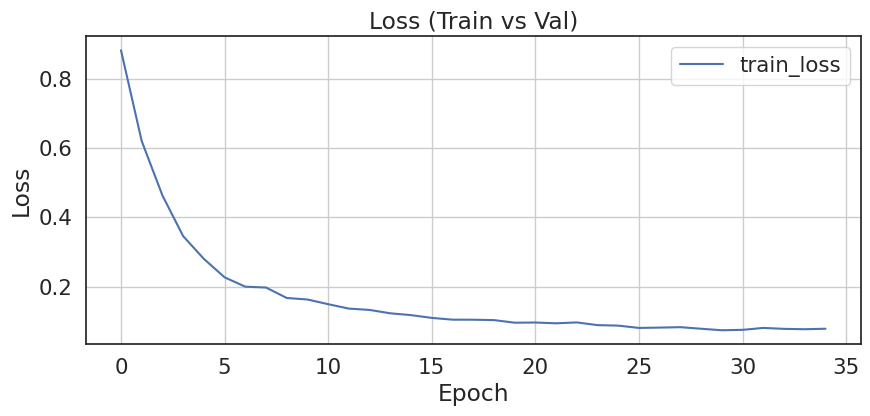

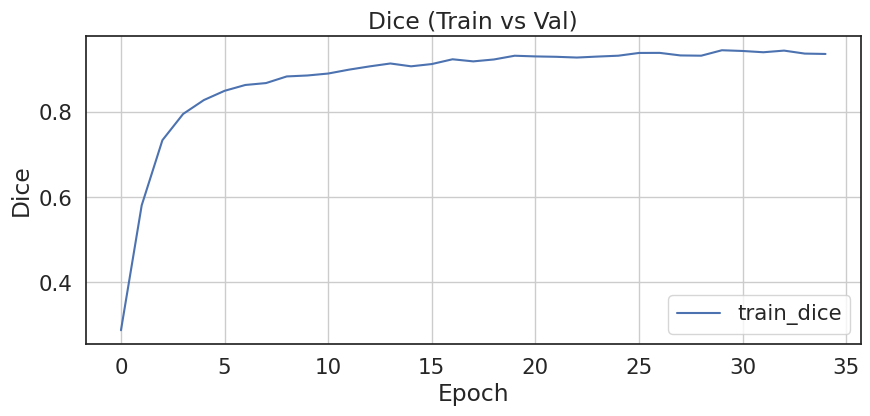


RETRAIN COMPLETATO
Best ckpt : /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/_CHECK/UnetPlusPlus_effb4_retrainTrainVal_35/retrain_trainval/best.ckpt
Metrics  : /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/_CHECK/UnetPlusPlus_effb4_retrainTrainVal_35/retrain_trainval/metrics.json


In [ ]:
TRAINVAL_CSV = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout/TrainVal.csv"
MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/_CHECK"

EPOCHS_SEG = 35
run_name = "UnetPlusPlus_effb4_retrainTrainVal_35"

model_cfg = {
  "arch": "unetpp",
  "encoder_name": "efficientnet-b4",
  "encoder_weights": "imagenet",
  "in_channels": 1,
  "classes": 1
}

metrics = retrain_full_models(
    X_all=X_train_val_clahe,
    y_all=y_train_val,
    masks_all=masks_train_val,
    filenames_all=loaded_filenames,
    epochs_seg=EPOCHS_SEG,
    trainval_csv_path=TRAINVAL_CSV,
    device=device,
    MODELS_DIR=MODELS_DIR,
    run_name=run_name,
    model_cfg=model_cfg,
    batch_size=16,
    num_workers=2,
    lr=1e-4,
    weight_decay=0,
    seed=SEED
)


## Retrain - All data

In [ ]:
# @title retrain

# @title Step 1)

from sklearn.model_selection import StratifiedShuffleSplit

def retrain_holdout_split(
    y,
    filenames,
    holdout_size=0.1,
    random_state=42,
    patient_id_fn=None,
    class_priority=None,
    verbose=True
):
    """
    Split Train/Val per retrain:
    - patient-consistent
    - stratificato per label a livello paziente (priority label)
    - ritorna df_train, df_val con indici globali 'idx'
    """
    if patient_id_fn is None:
        patient_id_fn = lambda fn: str(fn).split("_")[0].split(".")[0]

    if class_priority is None:
        class_priority = [1, 0, 2]  # MAL > BEN > NORMAL (adatta se serve)

    df = pd.DataFrame({
        "filename": np.asarray(filenames),
        "label_orig": np.asarray(y).astype(int),
        "idx": np.arange(len(y), dtype=int)
    })
    df["patient_id"] = df["filename"].apply(patient_id_fn)

    if verbose:
        print("="*60)
        print("RETRAIN HOLDOUT SPLIT (Train vs Val) — patient-consistent")
        print("="*60)
        print(f"Totale immagini: {len(df)}")
        print(f"Totale pazienti: {df['patient_id'].nunique()}")
        print(f"holdout_size  : {holdout_size}")

    # se holdout=0 -> tutto train, niente val
    if holdout_size is None or float(holdout_size) <= 0.0:
        if verbose:
            print("holdout_size=0 -> nessuna validation. Retrain su tutti i dati.")
        return df.copy(), None

    # priority label per paziente
    def get_patient_priority_label(patient_labels):
        classes_present = set(patient_labels)
        for c in class_priority:
            if c in classes_present:
                return c
        return list(classes_present)[0]

    patient_strat_labels = df.groupby("patient_id")["label_orig"].apply(get_patient_priority_label)
    unique_patients = patient_strat_labels.index.values
    stratify_values = patient_strat_labels.values

    sss = StratifiedShuffleSplit(n_splits=1, test_size=holdout_size, random_state=random_state)
    p_tr_idx, p_val_idx = next(sss.split(unique_patients, stratify_values))

    patients_train = unique_patients[p_tr_idx]
    patients_val   = unique_patients[p_val_idx]

    # leakage check
    inter = set(patients_train).intersection(set(patients_val))
    if inter:
        raise RuntimeError(f"LEAKAGE retrain holdout! Pazienti in comune train/val: {list(inter)[:5]}")

    df_train = df[df["patient_id"].isin(patients_train)].copy()
    df_val   = df[df["patient_id"].isin(patients_val)].copy()

    if verbose:
        print(f"\nTrain: {len(df_train)} immagini ({df_train['patient_id'].nunique()} pazienti)")
        print(f"Val:   {len(df_val)} immagini ({df_val['patient_id'].nunique()} pazienti)")

        def print_stats(df_, name):
            unique, counts = np.unique(df_["label_orig"].values, return_counts=True)
            tot = len(df_)
            print(f"Distribuzione immagini {name}:")
            for u, c in zip(unique, counts):
                print(f"  Classe {u}: {c} ({c/tot*100:.1f}%)")

        print_stats(df_train, "TRAIN")
        print_stats(df_val, "VAL")

    return df_train, df_val




###

# @title Step 2) Loader per retrain

from torch.utils.data import DataLoader

def build_retrain_loaders(
    X_all, y_all, masks_all, filenames_all,
    holdout_size=0.1,
    batch_size=8,
    num_workers=2,
    seed=42,
    patient_id_fn=None,
    class_priority=None,
    return_offline_data=False,
    verbose=True
):
    """
    Retrain finale su TrainVal con holdout interno (es. 10%) per early stopping.
    - train: offline augmentation + online augmentation
    - val  : NO augmentation (solo transform di validazione / o None)
    - se holdout_size=0 -> ritorna solo train_loader e val_loader=None
    """
    # 1) split patient-consistent
    df_train, df_val = retrain_holdout_split(
        y=y_all,
        filenames=filenames_all,
        holdout_size=holdout_size,
        random_state=seed,
        patient_id_fn=patient_id_fn,
        class_priority=class_priority,
        verbose=verbose
    )

    train_idx = df_train["idx"].values.astype(int)

    X_train = X_all[train_idx]
    y_train = np.asarray(y_all)[train_idx]
    masks_train = masks_all[train_idx]
    fn_train = np.asarray(filenames_all)[train_idx]

    # 2) Offline augmentation SOLO su train
    np.random.seed(seed)
    X_train_bal, y_train_bal, masks_train_bal, fn_train_bal = balance_dataset_offline(
        X_train, y_train, masks_train, fn_train
    )

    # 3) Online augmentation train
    train_ds = BreastUSDataset(
        X_train_bal, masks_train_bal, y_train_bal,
        filenames=fn_train_bal,
        transform=train_transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    # 4) Val loader (se esiste)
    val_loader = None
    if df_val is not None:
        val_idx = df_val["idx"].values.astype(int)

        X_val = X_all[val_idx]
        y_val = np.asarray(y_all)[val_idx]
        masks_val = masks_all[val_idx]
        fn_val = np.asarray(filenames_all)[val_idx]

        val_ds = BreastUSDataset(
            X_val, masks_val, y_val,
            filenames=fn_val,
            transform=val_transform if "val_transform" in globals() else None
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True
        )

    if return_offline_data:
        return train_loader, val_loader, X_train_bal, masks_train_bal, fn_train_bal

    return train_loader, val_loader


###

# @title Step 3) Retrain function

def train_one_fold_dice(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    n_epochs=50,
    patience=10,
    save_path_best=None,
    history_csv_path=None,
    fold_id=None,
    plot_history=True,
    # --- NEW: visualizzazione durante training ---
    viz_every=5,
    viz_loader=None,      # se None -> usa val_loader
    viz_kwargs=None       # dict: thr, area_thr, max_batches, n_samples, seed, ...
):
    history = {"loss": [], "val_loss": [], "dice": [], "val_dice": []}
    use_val = val_loader is not None

    best_score = -float("inf")
    best_val_dice = None
    val_loss_at_best_dice = None
    epochs_no_improve = 0

    if history_csv_path is not None:
        os.makedirs(os.path.dirname(history_csv_path), exist_ok=True)
    if save_path_best is not None:
        os.makedirs(os.path.dirname(save_path_best), exist_ok=True)

    tag = f"[FOLD {fold_id}] " if fold_id is not None else ""
    print(f"{tag}Starting training for {n_epochs} epochs")
    print(f"{'='*60}\n")

    if viz_kwargs is None:
        viz_kwargs = {}
    if viz_loader is None:
        viz_loader = val_loader  # default: mostra sul validation set

    for epoch in range(n_epochs):
        # ---------------- TRAIN ----------------
        model.train()
        train_loss = 0.0
        train_dice = 0.0

        loop = tqdm(train_loader, total=len(train_loader),
                    desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [TRAIN]", leave=True)

        for imgs, masks, _, _ in loop:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(imgs)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            batch_dice = dice_coefficient(torch.sigmoid(outputs), masks)

            train_loss += loss.item()
            train_dice += batch_dice
            loop.set_postfix(loss=loss.item(), dice=batch_dice)

        train_loss /= len(train_loader)
        train_dice /= len(train_loader)

        # ---------------- VALIDATION ----------------
        if use_val:
            model.eval()
            val_loss = 0.0
            val_dice = 0.0

            with torch.no_grad():
                val_loop = tqdm(val_loader, total=len(val_loader),
                                desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [VAL]", leave=False)

                for imgs, masks, _, _ in val_loop:
                    imgs, masks = imgs.to(device), masks.to(device)

                    outputs = model(imgs)
                    loss = criterion(outputs, masks)
                    batch_dice = dice_coefficient(torch.sigmoid(outputs), masks)

                    val_loss += loss.item()
                    val_dice += batch_dice
                    val_loop.set_postfix(loss=loss.item(), dice=batch_dice)

            val_loss /= len(val_loader)
            val_dice /= len(val_loader)
        else:
            val_loss = None
            val_dice = None

        # ---------------- HISTORY + CSV ----------------
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["dice"].append(train_dice)
        history["val_dice"].append(val_dice)

        if history_csv_path is not None:
            pd.DataFrame(history).to_csv(history_csv_path, index=False)

        # ---------------- SCHEDULER ----------------
        if scheduler is not None:
            if use_val:
                scheduler.step(val_dice)
            else:
                scheduler.step(train_dice)

        # ---------------- LOG ----------------
        if use_val:
            print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
        else:
            print(f"\nEpoch [{epoch+1}/{n_epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
                  f"(no validation)")

        # ---------------- NEW: VISUALIZZAZIONE OGNI K EPOCHE ----------------
        if (viz_every is not None) and (viz_every > 0) and (viz_loader is not None):
            if ((epoch + 1) % viz_every == 0) or (epoch == 0):
                print(f"{tag}🔎 Visualizing predictions @ epoch {epoch+1}")
                # seed deterministico per epoch (così non vedi sempre le stesse)
                viz_seed = viz_kwargs.get("seed", 0)
                viz_kwargs_epoch = dict(viz_kwargs)
                viz_kwargs_epoch["seed"] = int(viz_seed) + int(epoch + 1) + (0 if fold_id is None else 1000 * int(fold_id))

                show_predictions_examples(
                    model=model,
                    loader=viz_loader,
                    device=device,
                    title_prefix=f"{tag}[EPOCH {epoch+1}] ",
                    **viz_kwargs_epoch
                )

        # ---------------- EARLY STOPPING (SU DICE) ----------------
        current_score = val_dice if use_val else train_dice  # maximize

        if current_score > best_score:
            best_score = current_score
            epochs_no_improve = 0

            best_val_dice = float(val_dice) if use_val else float(train_dice)
            val_loss_at_best_dice = float(val_loss) if use_val else float(train_loss)

            if save_path_best is not None:
                torch.save({
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": float(train_loss),
                    "val_loss": float(val_loss) if val_loss is not None else None,
                    "train_dice": float(train_dice),
                    "val_dice": float(val_dice) if val_dice is not None else None,
                    "best_score": float(best_score),
                }, save_path_best)

            if use_val:
                print(f"{tag}  💾 Saved new best model. Val Dice {best_val_dice:.4f}")
            else:
                print(f"{tag}  💾 Saved new best model. Train Dice {best_val_dice:.4f}")
        else:
            epochs_no_improve += 1
            print(f"{tag}  No improvement for {epochs_no_improve}/{patience} epoch(s)")

        print(f"{'─'*60}\n")

        if use_val and epochs_no_improve >= patience:
            print(f"\n{'='*60}")
            print(f"{tag}🛑 Early stopping triggered after {epoch+1} epochs!")
            print(f"{tag}Best Val Dice: {best_val_dice:.4f}")
            print(f"{tag}Val Loss @ Best Dice: {val_loss_at_best_dice:.4f}")
            if history_csv_path is not None:
                print(f"{tag}History CSV: {history_csv_path}")
            print(f"{'='*60}\n")
            break

    if use_val:
        print(f"{tag}Training finished. Best Val Dice: {best_val_dice:.4f} | "
              f"Val Loss @ Best Dice: {val_loss_at_best_dice:.4f}")
    else:
        print(f"{tag}Training finished. Best Train Dice: {best_val_dice:.4f} | (no validation)")

    # ---------------- PLOTS ----------------
    if plot_history:
        plt.figure(figsize=(10, 4))
        plt.plot(history["loss"], label="train_loss")
        if use_val:
            plt.plot(history["val_loss"], label="val_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{tag}Loss (Train vs Val)")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(history["dice"], label="train_dice")
        if use_val:
            plt.plot(history["val_dice"], label="val_dice")
        plt.xlabel("Epoch")
        plt.ylabel("Dice")
        plt.title(f"{tag}Dice (Train vs Val)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        "best_val_dice": float(best_val_dice) if best_val_dice is not None else None,
        "val_loss_at_best_dice": float(val_loss_at_best_dice) if val_loss_at_best_dice is not None else None,
        "history": history
    }

###

# @title Wrapper run

def run_retrain_dice(
    X_all, y_all, masks_all, filenames_all,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    holdout_size=0.1,          # puoi metterlo a 0
    n_epochs=50,
    patience=10,
    batch_size=8,
    num_workers=2,
    lr=1e-4,
    weight_decay=1e-3,
    seed=42,
    patient_id_fn=None,
    class_priority=None,
):
    # 0) seed
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # 1) loaders (holdout patient-consistent)
    train_loader, val_loader = build_retrain_loaders(
        X_all=X_all, y_all=y_all, masks_all=masks_all, filenames_all=filenames_all,
        holdout_size=holdout_size,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        patient_id_fn=patient_id_fn,
        class_priority=class_priority,
        return_offline_data=False,
        verbose=True
    )

    # 2) paths (no fold)
    out_dir = os.path.join(MODELS_DIR, run_name, "retrain")
    os.makedirs(out_dir, exist_ok=True)
    best_path = os.path.join(out_dir, "best.ckpt")
    history_csv = os.path.join(out_dir, "history.csv")

    # 3) model / loss / optim / sched (come nel fold)
    model = make_model(
        arch=model_cfg["arch"],
        encoder_name=model_cfg["encoder_name"],
        encoder_weights=model_cfg.get("encoder_weights", "imagenet"),
        in_channels=model_cfg.get("in_channels", 1),
        classes=model_cfg.get("classes", 1),
        device=device
    )

    dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
    focal_loss = smp.losses.FocalLoss(mode='binary')
    def criterion(logits, target):
        return dice_loss(logits, target) + focal_loss(logits, target)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    # 4) train
    out = train_one_fold_dice(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        n_epochs=n_epochs,
        patience=patience,
        save_path_best=best_path,
        history_csv_path=history_csv,
        fold_id=None,
        plot_history=True,
        viz_every=5,
        viz_loader=val_loader,
        viz_kwargs=dict(thr=0.5, area_thr=0, max_batches=2, n_samples=2, seed=seed)
    )

    # ---------------- FINAL SUMMARY ----------------
    print("\n" + "="*90)
    print("RETRAIN SUMMARY")
    print("="*90)

    if holdout_size > 0:
        print(f"Dice (pixel-wise, val) : {out['best_val_dice']:.4f}")
        print(f"Val loss @ best Dice   : {out['val_loss_at_best_dice']:.4f}")
    else:
        print(f"Dice (pixel-wise, train): {out['best_val_dice']:.4f}")

    print(f"Best checkpoint        : {best_path}")
    print("="*90)

    return {
        "best_path": best_path,
        "history_csv": history_csv,
        **out
    }

    return {
        "best_path": best_path,
        "history_csv": history_csv,
        **out
    }


RETRAIN HOLDOUT SPLIT (Train vs Val) — patient-consistent
Totale immagini: 1503
Totale pazienti: 968
holdout_size  : 0
holdout_size=0 -> nessuna validation. Retrain su tutti i dati.
BILANCIAMENTO DATASET OFFLINE (Con Verifica Filename)
Distribuzione Iniziale: {np.int64(0): np.int64(679), np.int64(1): np.int64(364), np.int64(2): np.int64(460)}
Target per classe: 679
> Classe 0: Già bilanciata.

> Classe 1: Generazione di 315 copie sintetiche...

> Classe 2: Generazione di 219 copie sintetiche...
Generazione completata. Dataset finale: 2037
Starting training for 35 epochs



Epoch [1/35] [TRAIN]: 100%|██████████| 255/255 [00:35<00:00,  7.13it/s, dice=0.384, loss=0.669]



Epoch [1/35] | Train Loss: 0.7850 | Train Dice: 0.3837 | (no validation)
  💾 Saved new best model. Train Dice 0.3837
────────────────────────────────────────────────────────────



Epoch [2/35] [TRAIN]: 100%|██████████| 255/255 [00:22<00:00, 11.39it/s, dice=0.574, loss=0.301]



Epoch [2/35] | Train Loss: 0.4789 | Train Dice: 0.6941 | (no validation)
  💾 Saved new best model. Train Dice 0.6941
────────────────────────────────────────────────────────────



...


Epoch [33/35] | Train Loss: 0.0829 | Train Dice: 0.9403 | (no validation)
  No improvement for 3/0 epoch(s)
────────────────────────────────────────────────────────────



Epoch [34/35] [TRAIN]: 100%|██████████| 255/255 [00:22<00:00, 11.43it/s, dice=0.926, loss=0.0815]



Epoch [34/35] | Train Loss: 0.1021 | Train Dice: 0.9208 | (no validation)
  No improvement for 4/0 epoch(s)
────────────────────────────────────────────────────────────



Epoch [35/35] [TRAIN]: 100%|██████████| 255/255 [00:22<00:00, 11.48it/s, dice=0.956, loss=0.0497]



Epoch [35/35] | Train Loss: 0.0837 | Train Dice: 0.9352 | (no validation)
  No improvement for 5/0 epoch(s)
────────────────────────────────────────────────────────────

Training finished. Best Train Dice: 0.9440 | (no validation)


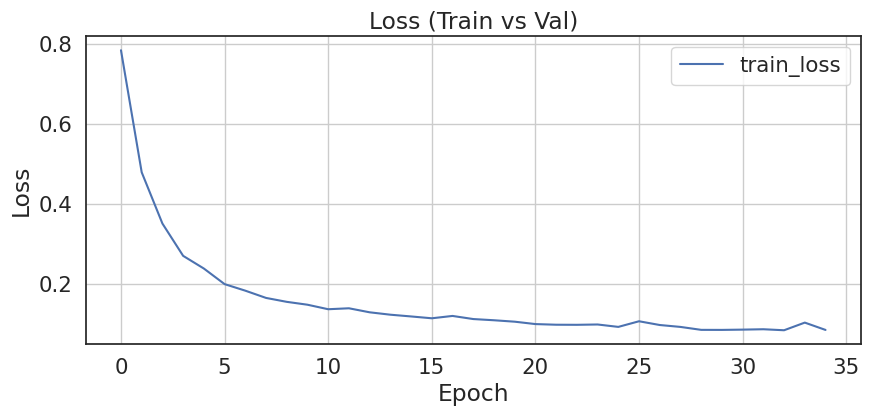

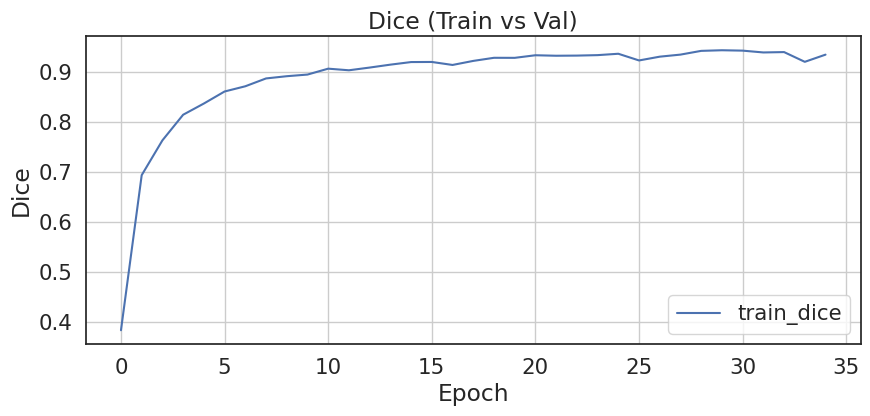


RETRAIN SUMMARY
Dice (pixel-wise, train): 0.9440
Best checkpoint        : /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS/UnetPlusPlus_effb4_DiceFocal_earlyStoppingDice_retrain_all/retrain/best.ckpt


In [ ]:
MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS"
run_name = "UnetPlusPlus_effb4_DiceFocal_earlyStoppingDice_retrain_all"

model_cfg = {
  "arch": "unetpp",
  "encoder_name": "efficientnet-b4",
  "encoder_weights": "imagenet",
  "in_channels": 1,
  "classes": 1
}

EPOCHS = 35
patient_id_fn = lambda fn: str(fn).split("_")[0].split(".")[0]

retrain_out = run_retrain_dice(
    X_all=X_train_val_clahe,
    y_all=y_train_val,
    masks_all=masks_train_val,
    filenames_all=loaded_filenames,
    device=device,
    MODELS_DIR=MODELS_DIR,
    run_name=run_name,
    model_cfg=model_cfg,
    holdout_size=0,
    n_epochs=EPOCHS,
    patience=0,
    seed=SEED,
    patient_id_fn=patient_id_fn,
    class_priority=[1,0,2],
)